#Retail Sales Volume Predictor

## Objectives

- Load and understand the raw retail dataset.
- Clean and prepare the data for analysis and modelling.
- Explore relationships between product attributes, merchandising conditions, and sales volume.
- Build and evaluate regression models to predict sales volume.
- Generate visualisations and features for a Streamlit dashboard.

## Inputs

- Raw dataset: `data/raw-data/...` (original CSV from Kaggle - https://www.kaggle.com/datasets/marixe/zara-sales-for-eda).
- Cleaned dataset: `data/cleaned-data/cleaned_data.csv`.
- Python scripts in `src/`:
  - `cleaning.py`
  - `modelling.py`
  - `promotion-v-position.py`
  - `visualisations.py`


## Outputs

- Cleaned dataset saved to `data/cleaned-data/cleaned_data.csv`.
- Visualisations saved to `visuals/`.
- Streamlit dashboard (separate app) using these artefacts.

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [ ]:
import os
current_dir = os.getcwd()
current_dir

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [ ]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

Confirm the new current directory

In [ ]:
current_dir = os.getcwd()
current_dir

Methodology

This project aims to build a predictive model for retail sales volume using historical product, pricing, and merchandising data. The goal is to:

- understand how factors like price, promotion, seasonality, product position, and category influence sales

- create a clean, reliable dataset suitable for modelling

- develop and compare regression models to predict sales_volume

- generate visual and numerical evidence to support merchandising and pricing decisions

- integrate the results into a Streamlit dashboard for interactive exploration and prediction

The methodology follows a structured, step‑by‑step data science workflow: from raw data to cleaned data, from EDA to modelling, and finally to an interactive Streamlit dashboard.

---

# Capstone Project — Retail Sales Volume Prediction

This notebook documents the full end‑to‑end process of:
- preparing the dataset
- exploring key relationships
- building and evaluating predictive models
- generating artefacts for a Streamlit dashboard

The code for cleaning, visualisation, and modelling lives in modular `.py` files in the `src/` folder.  
Here, I **call those functions** and focus on explaining the **reasoning and outcomes**.

Below I am setting up my ntoebook environment, allowing me to load the .py files where I have all my functions that cleans my data, creates visuals and runs my model.

In [1]:
import os
import sys
import pandas as pd
from IPython.display import Image

# Find the project root (folder containing src/)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("Project root:", project_root)

# Add project root to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

# Now imports will work
from src.cleaning import clean_data
from src.modelling import train_models



Project root: c:\Users\cowar\OneDrive\Documents\vs-code-projects\capstone-project


Firstly I wanted to inspect and understand the raw data. I loaded the raw data into a cleaning.py file and created functions that:

1. Standardises column names  
2. Removes missing values  
3. Summarises duplicates  
4. Detects outliers (kept, not removed)  
5. Engineers new features  
6. Encodes categorical variables  
7. Rebuilds `product_position`  
8. Performs final validation checks  
9. Saves cleaned dataset 

When inspecting the data, I was looking for potential features that could impact sales volume such as promotion, seasonality, category types, price etc. 

In [2]:
# Clean the raw data and keep the returned dataframe for the next stages.
cleaned_df = clean_data()
cleaned_df.head()
cleaned_df.info()
cleaned_df.describe()


--- SHAPE ---
Rows: 20252, Columns: 17

--- HEAD ---
   Product ID Product Position Promotion Product Category Seasonal  \
0      185102            Aisle       Yes         clothing      Yes   
1      188771            Aisle       Yes         clothing       No   
2      180176          End-cap       Yes         clothing      Yes   
3      112917            Aisle       Yes         clothing       No   
4      192936          End-cap       Yes         clothing      Yes   

   Sales Volume brand                                                url  \
0          1243  Zara  https://www.zara.com/us/en/basic-puffer-jacket...   
1          1429  Zara  https://www.zara.com/us/en/tuxedo-jacket-p0889...   
2          1168  Zara  https://www.zara.com/us/en/slim-fit-suit-jacke...   
3          1348  Zara  https://www.zara.com/us/en/stretch-suit-jacket...   
4          1602  Zara  https://www.zara.com/us/en/double-faced-jacket...   

                   name                                        descr

,product_id,promotion,seasonal,sales_volume,price
count,20250.000000,20250.00000,20250.000000,20250.000000,20250.000000
mean,208935.993383,0.41679,0.499457,1097.428148,41.950592
std,8949.110701,0.49304,0.500012,298.236187,23.381581
min,110075.000000,0.00000,0.000000,518.000000,12.000000
25%,204444.250000,0.00000,0.000000,849.000000,23.950000
50%,209506.500000,0.00000,0.000000,990.000000,35.950000
75%,214568.750000,1.00000,1.000000,1364.750000,53.950000
max,219631.000000,1.00000,1.000000,1940.000000,134.990000


## Exploratory Data Analysis (EDA)

Below I will bring in my visuals and talk through each one from `visuals/eda/` folder, with the code creating these in this file: `src/visualisations.py`

In [3]:
#bringing in the visualisations module

from src.visualisations import (
    plot_sales_volume_distribution,
    plot_price_distribution,
    plot_product_category,
    plot_promotion_vs_sales,
    plot_correlation_heatmap,
    plot_sales_volume_by_category,
    plot_sales_volume_by_position,
    plot_promotion_effectiveness,
    plot_price_vs_sales,
    plot_outlier_boxplots,
    plot_pairplot,
    rebuild_product_position
)

---

### Outlier Boxplot

The Outlier boxplot shows that price has several outliers in price which represent the higher valued products in a retail range such as coats or premium products. As these are a true reflection of the range and not an outlier which will skew the data, I have kept them in. In the Sales Volume boxplot there are no outliers which shows a stable dataset and ready for modelling.

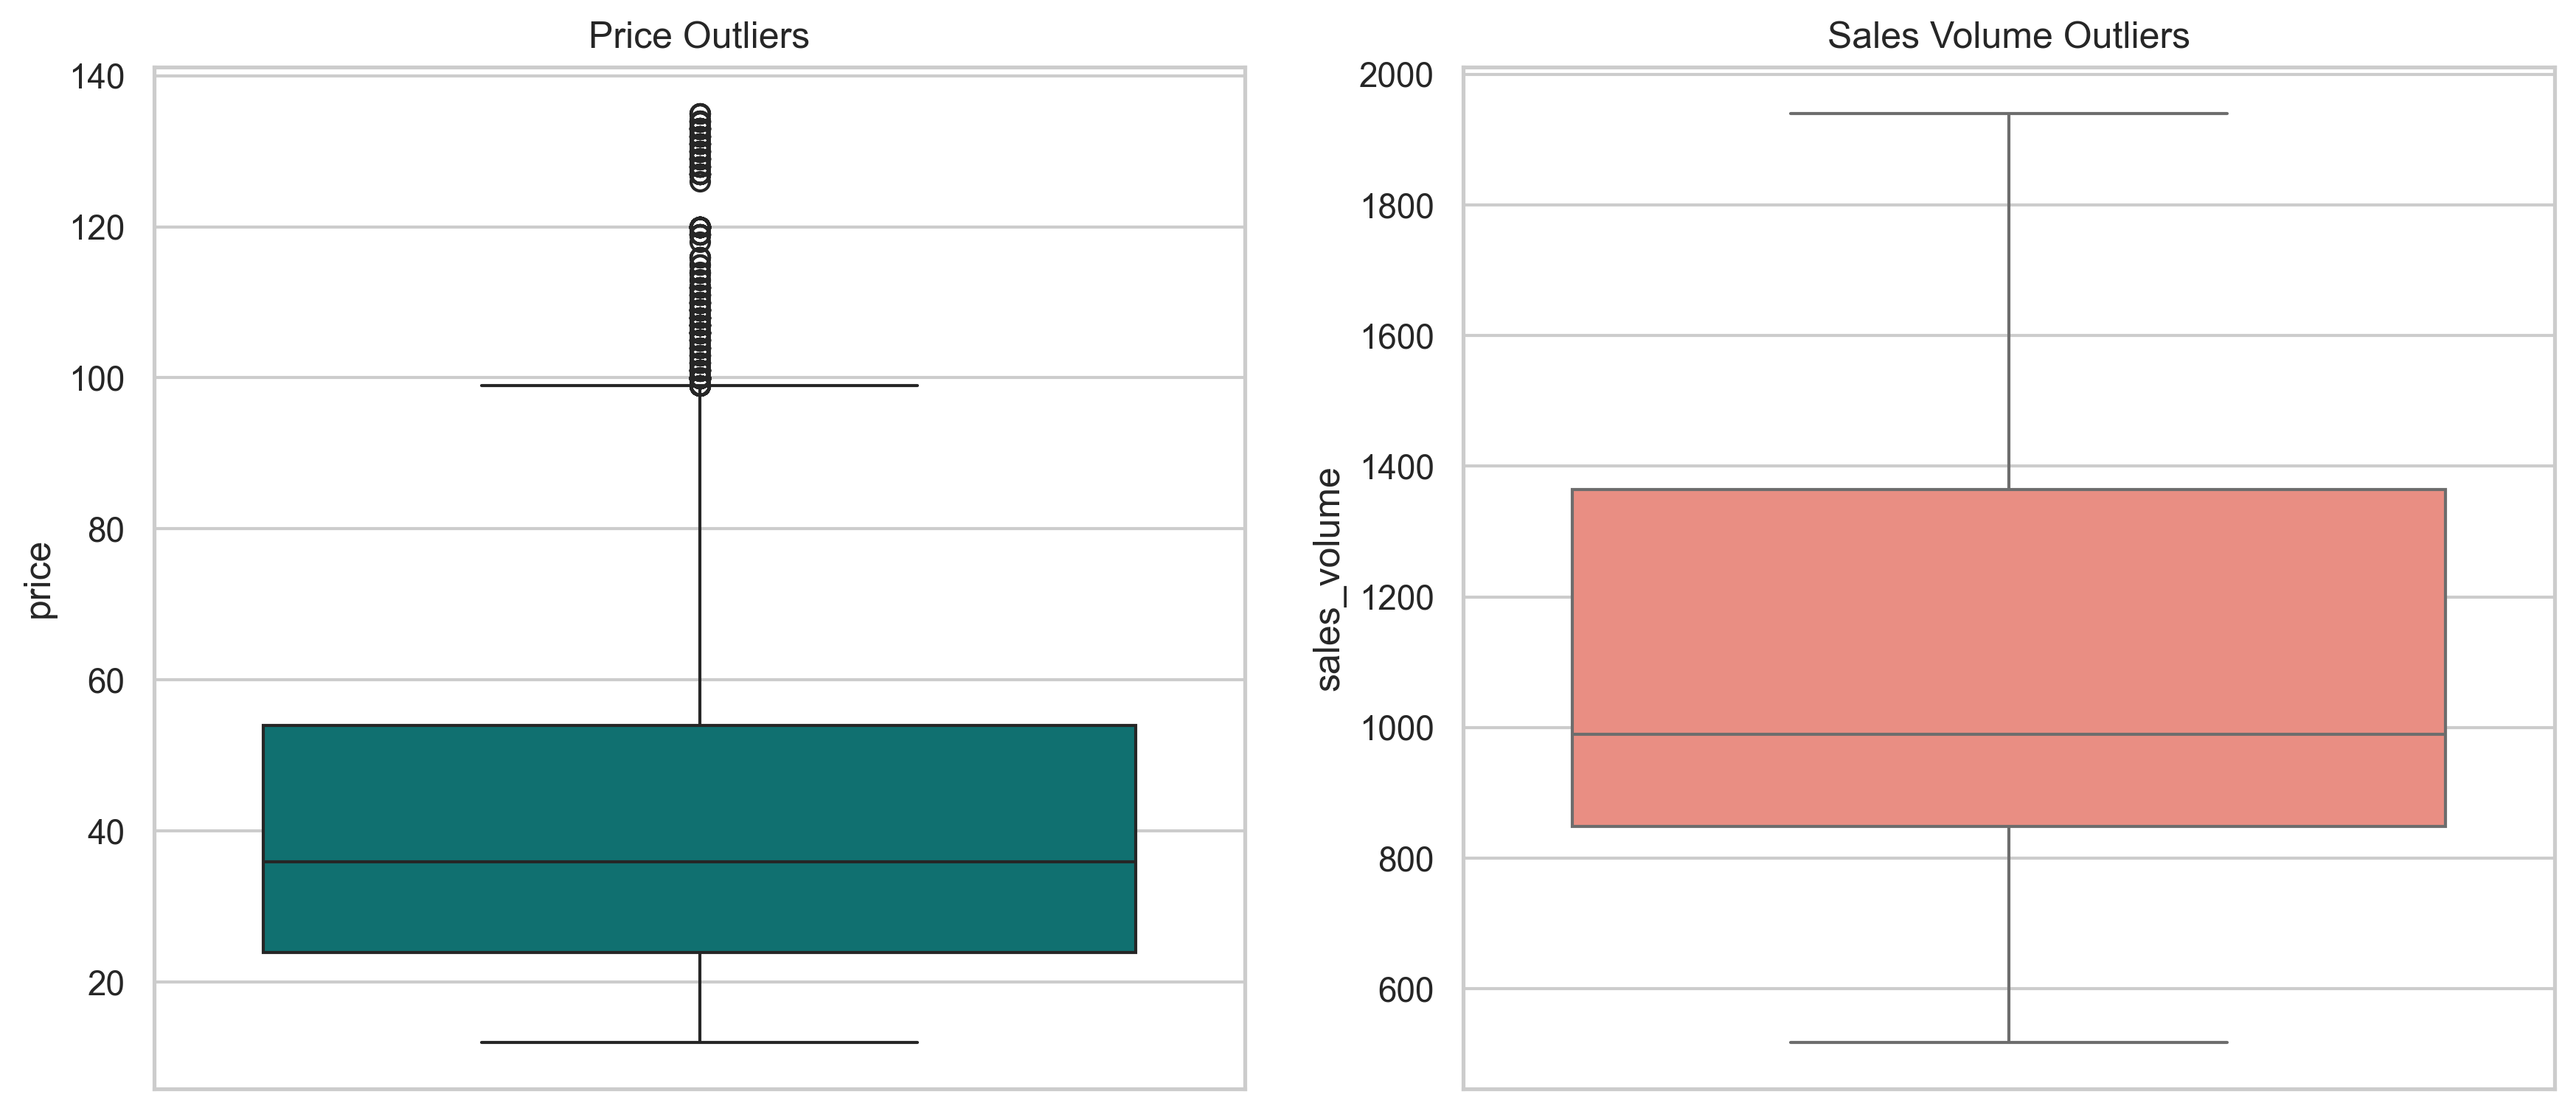

In [4]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "outlier_boxplots.png")
Image(img_path)

### Price Distribution

The Price Distribution histogram shows me how the products prices are spread out, and it's telling me that most items are pretty cheap with the bulk of them priced between £10 to £40. After that the bars thin out which shows fewer items are priced higher. This story is replicated on the Price boxplot with the main box showing most items sit in the £20-40 prices, and the dots represent the higher priced products such as premium items or higher ASP such as Coats. 

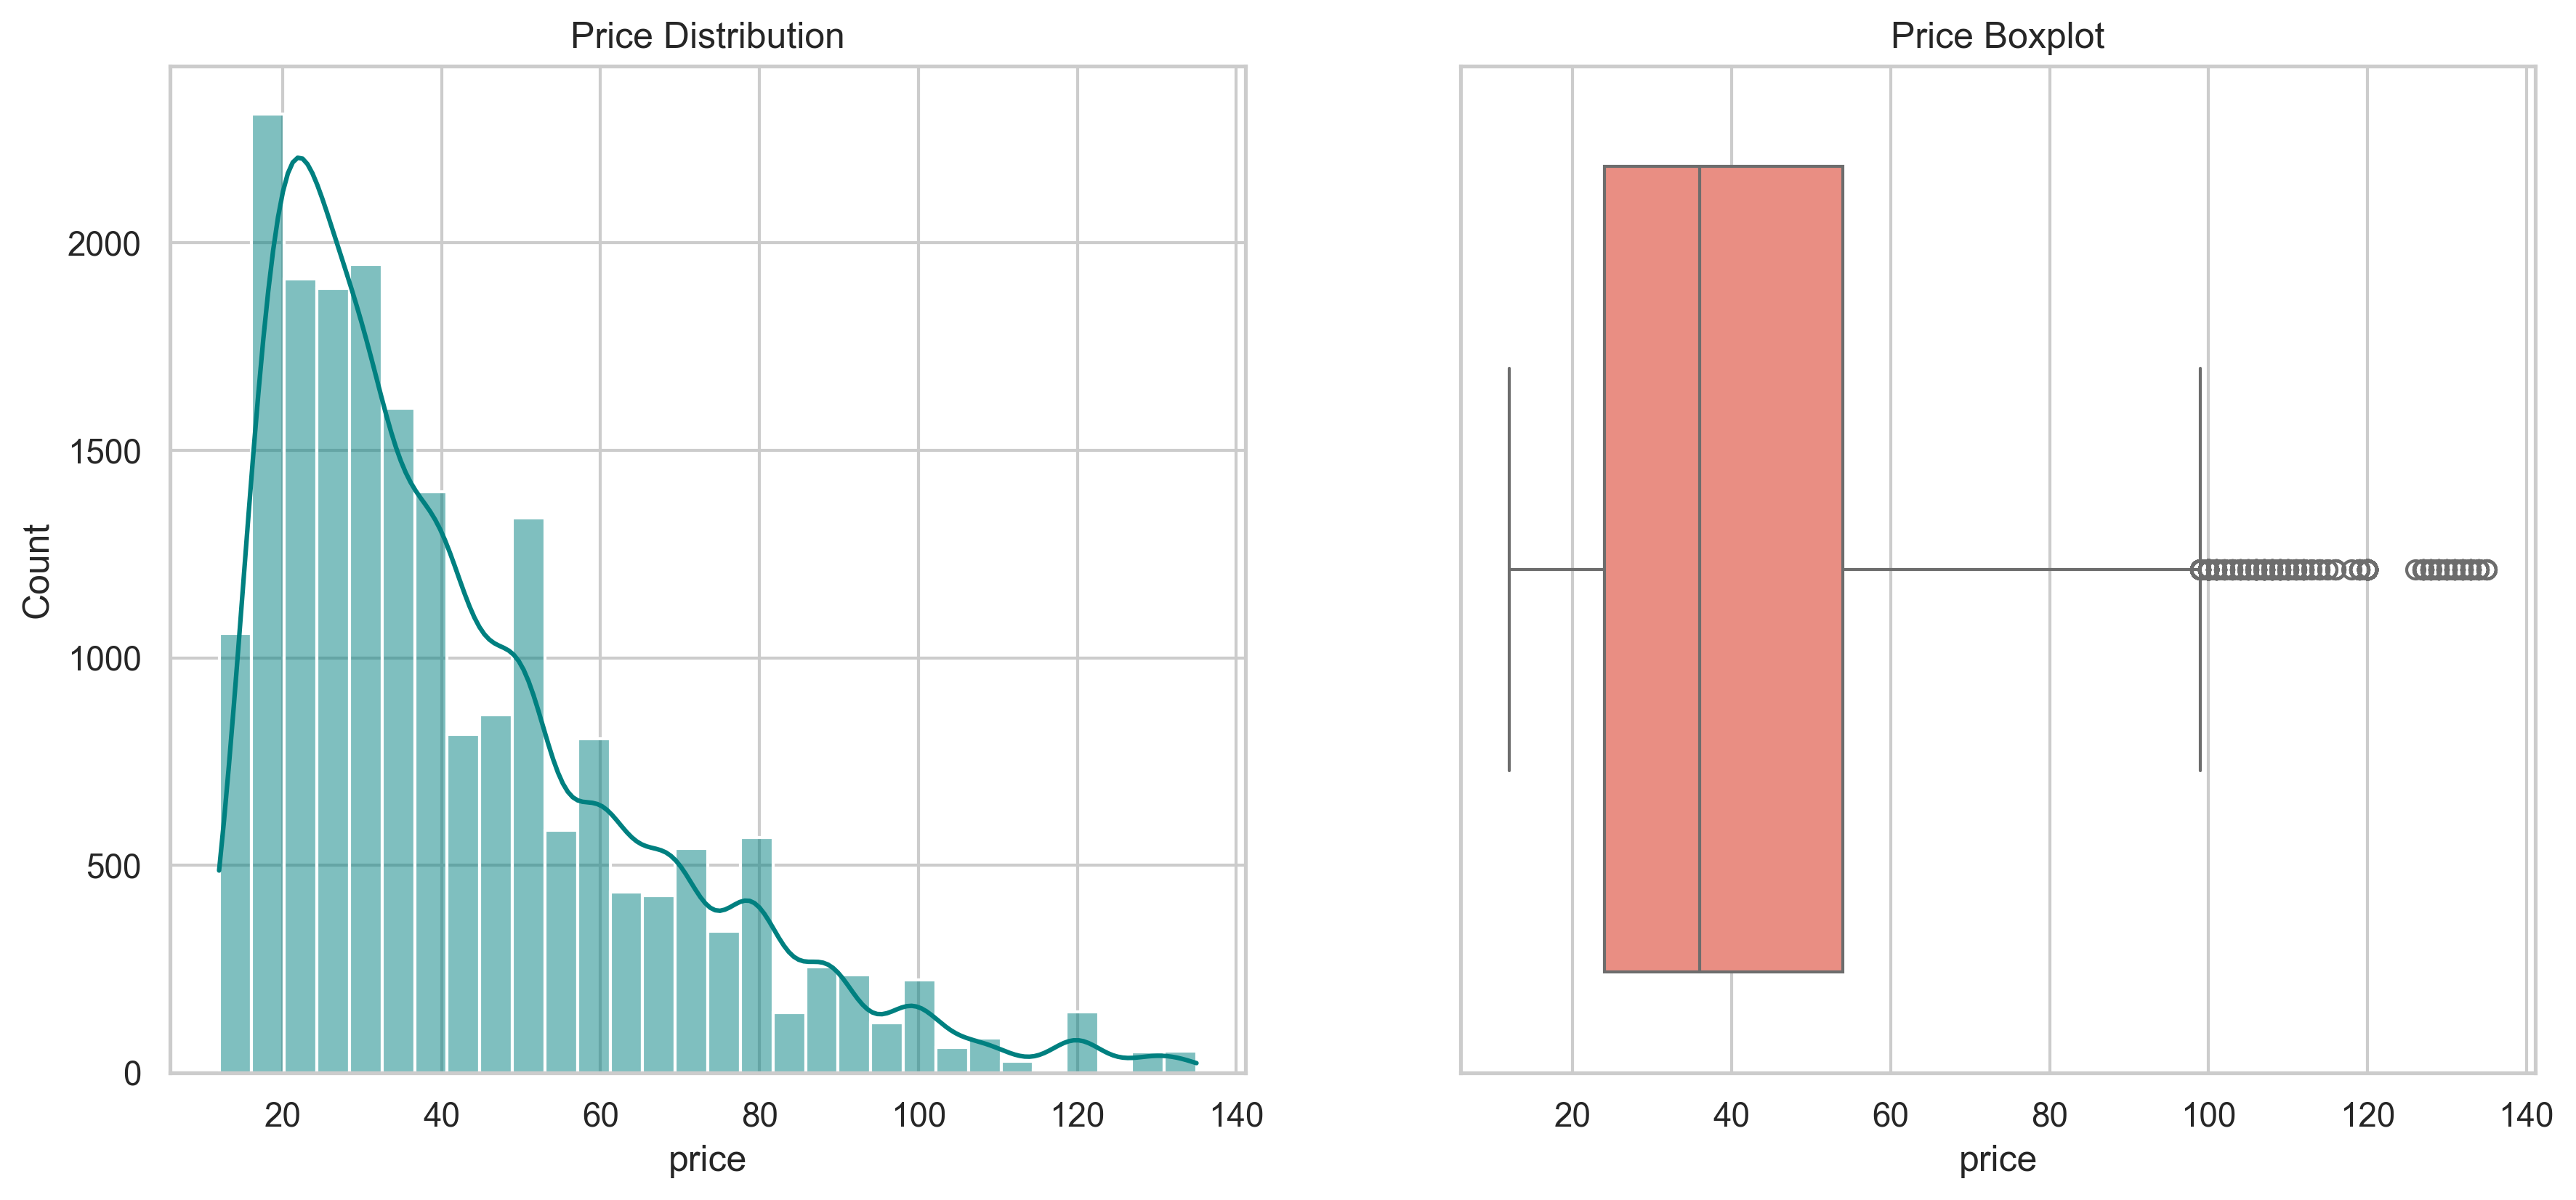

In [5]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "price_distribution.png")
Image(img_path)

### Sales Volume Distribution

When running the Sales Volume Distribution chart we can see two peaks which indicates two groups of different sales behaviours. This could be sales driven by promo vs no promo or items positioned in different areas in the store.

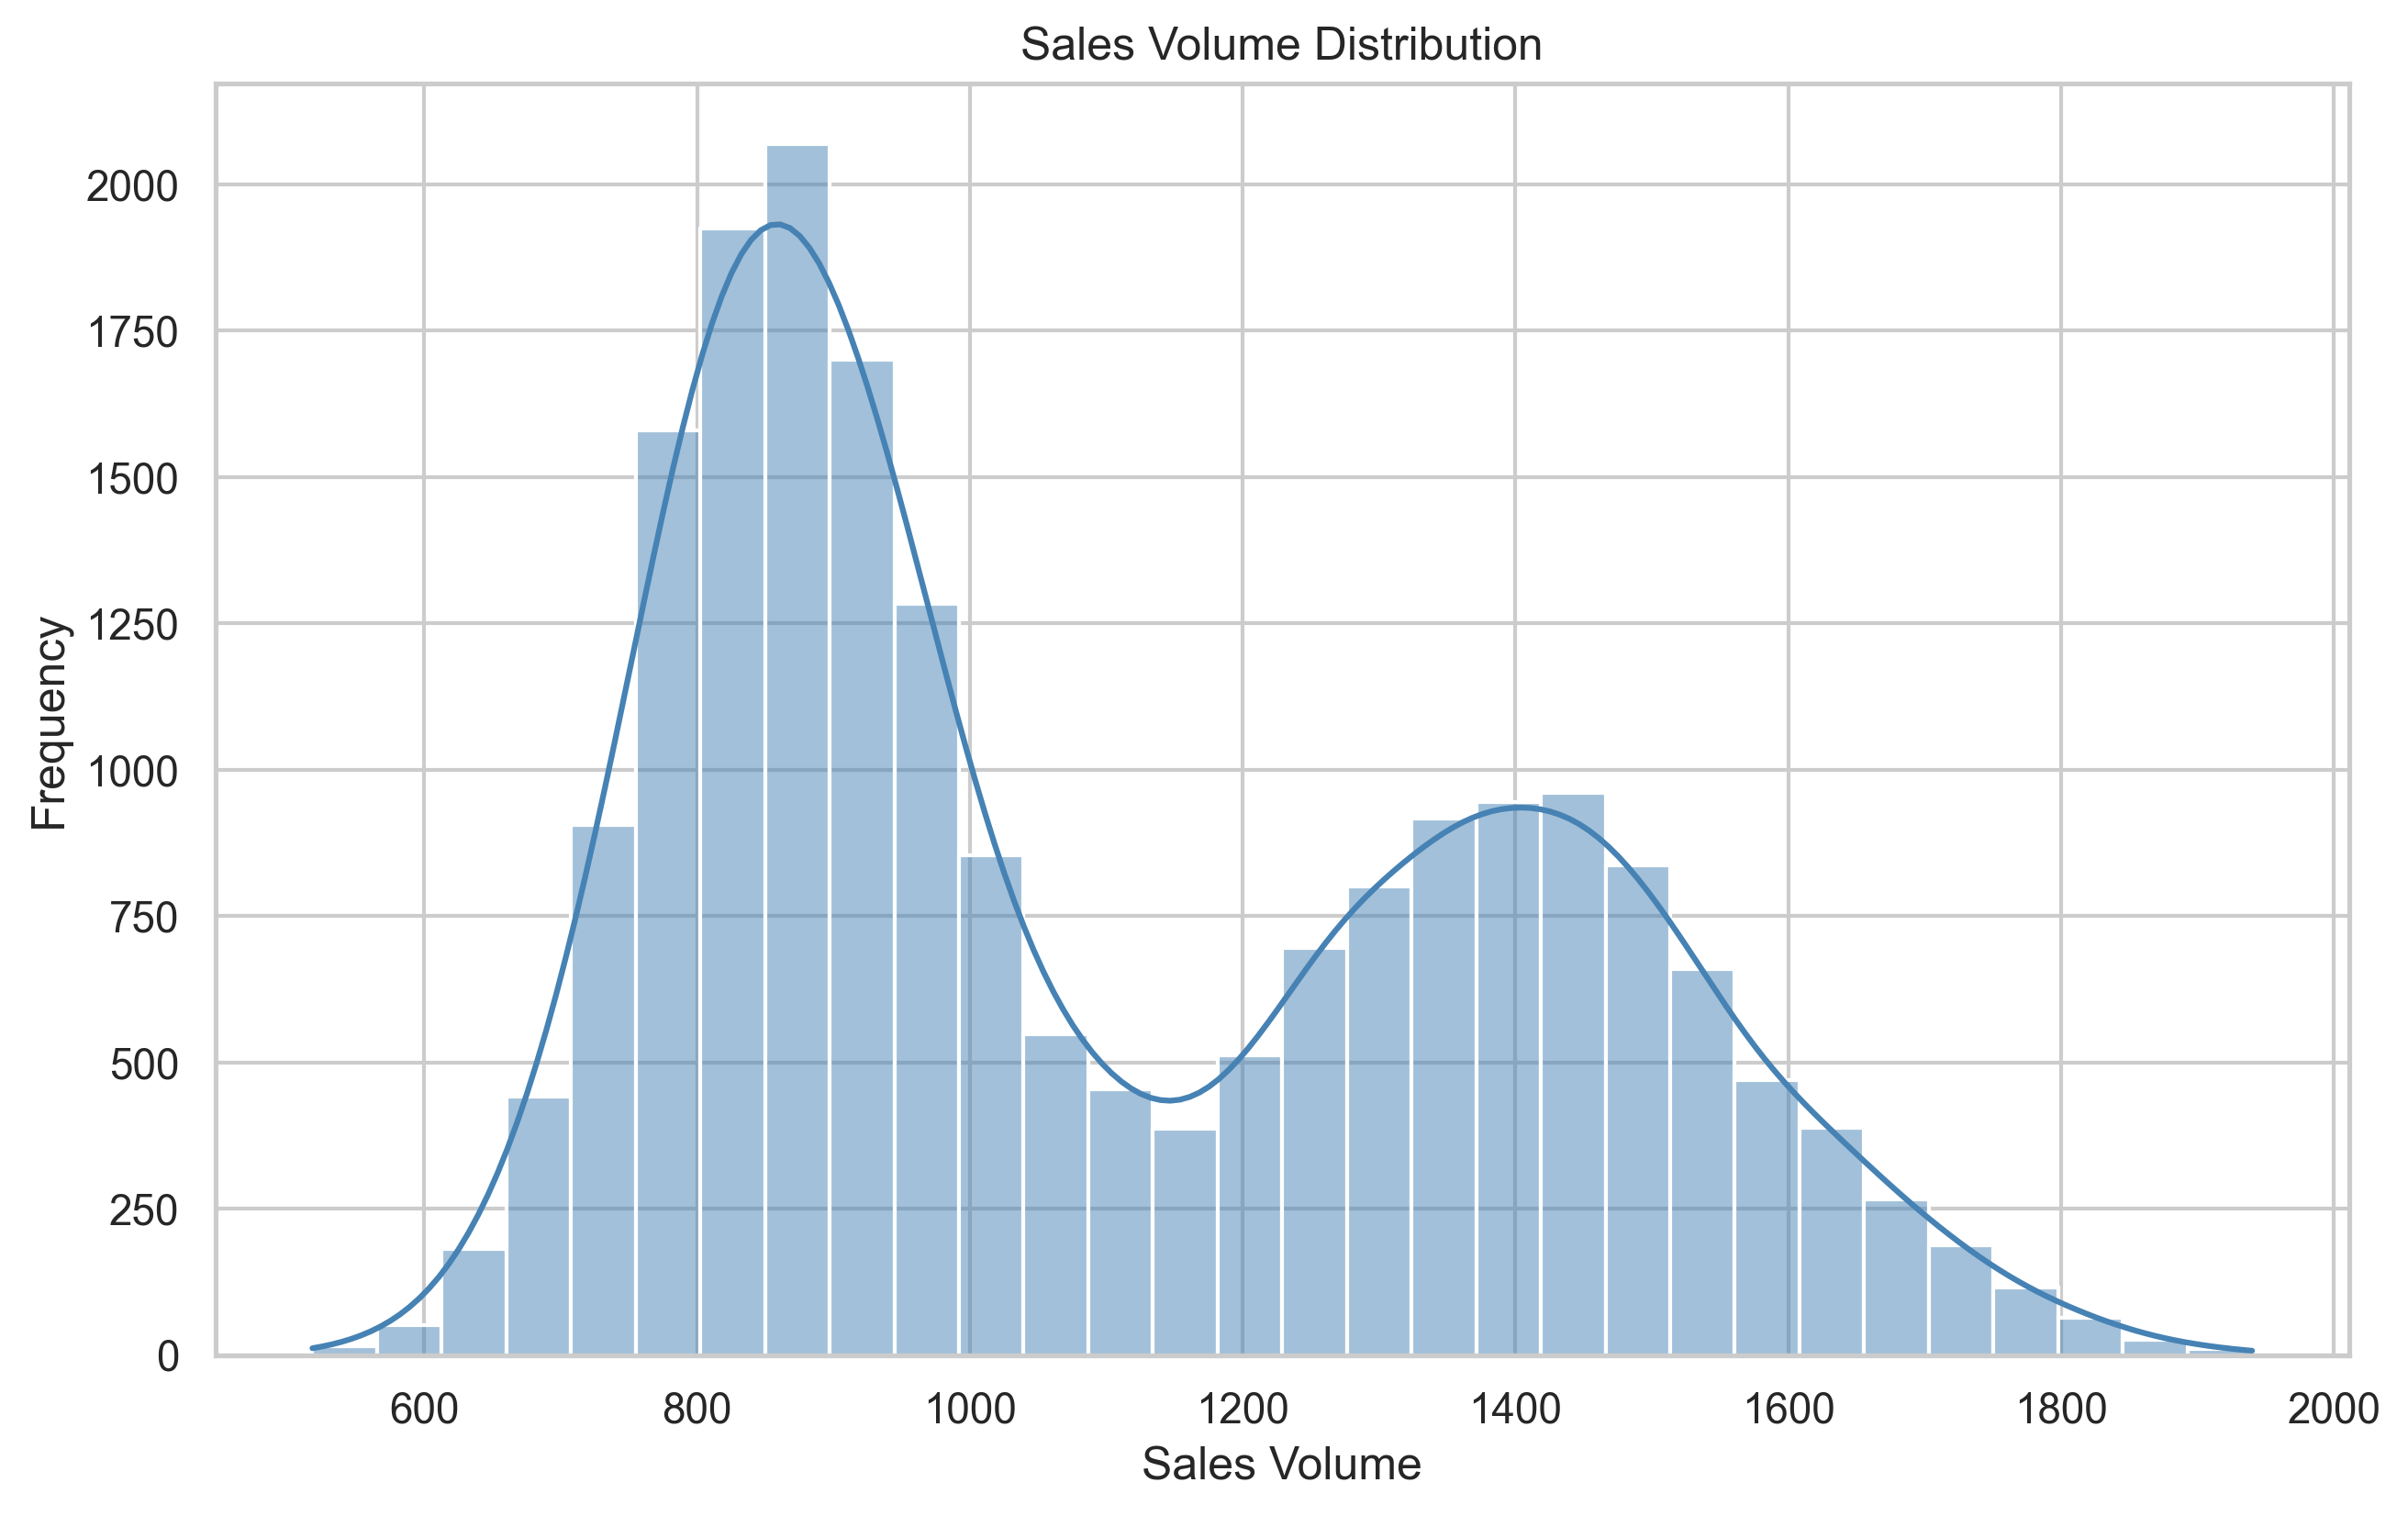

In [6]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "sales_volume_distribution.png")
Image(img_path)

### Product Category Distribution

When reviewing the distribution of products by category we can see that Jackets have the highest count of our product range followed by sweaters and t-shirts. As there are lots of jackets it made me question the ASP of £10 - £40 so I wanted to look at price by category. 

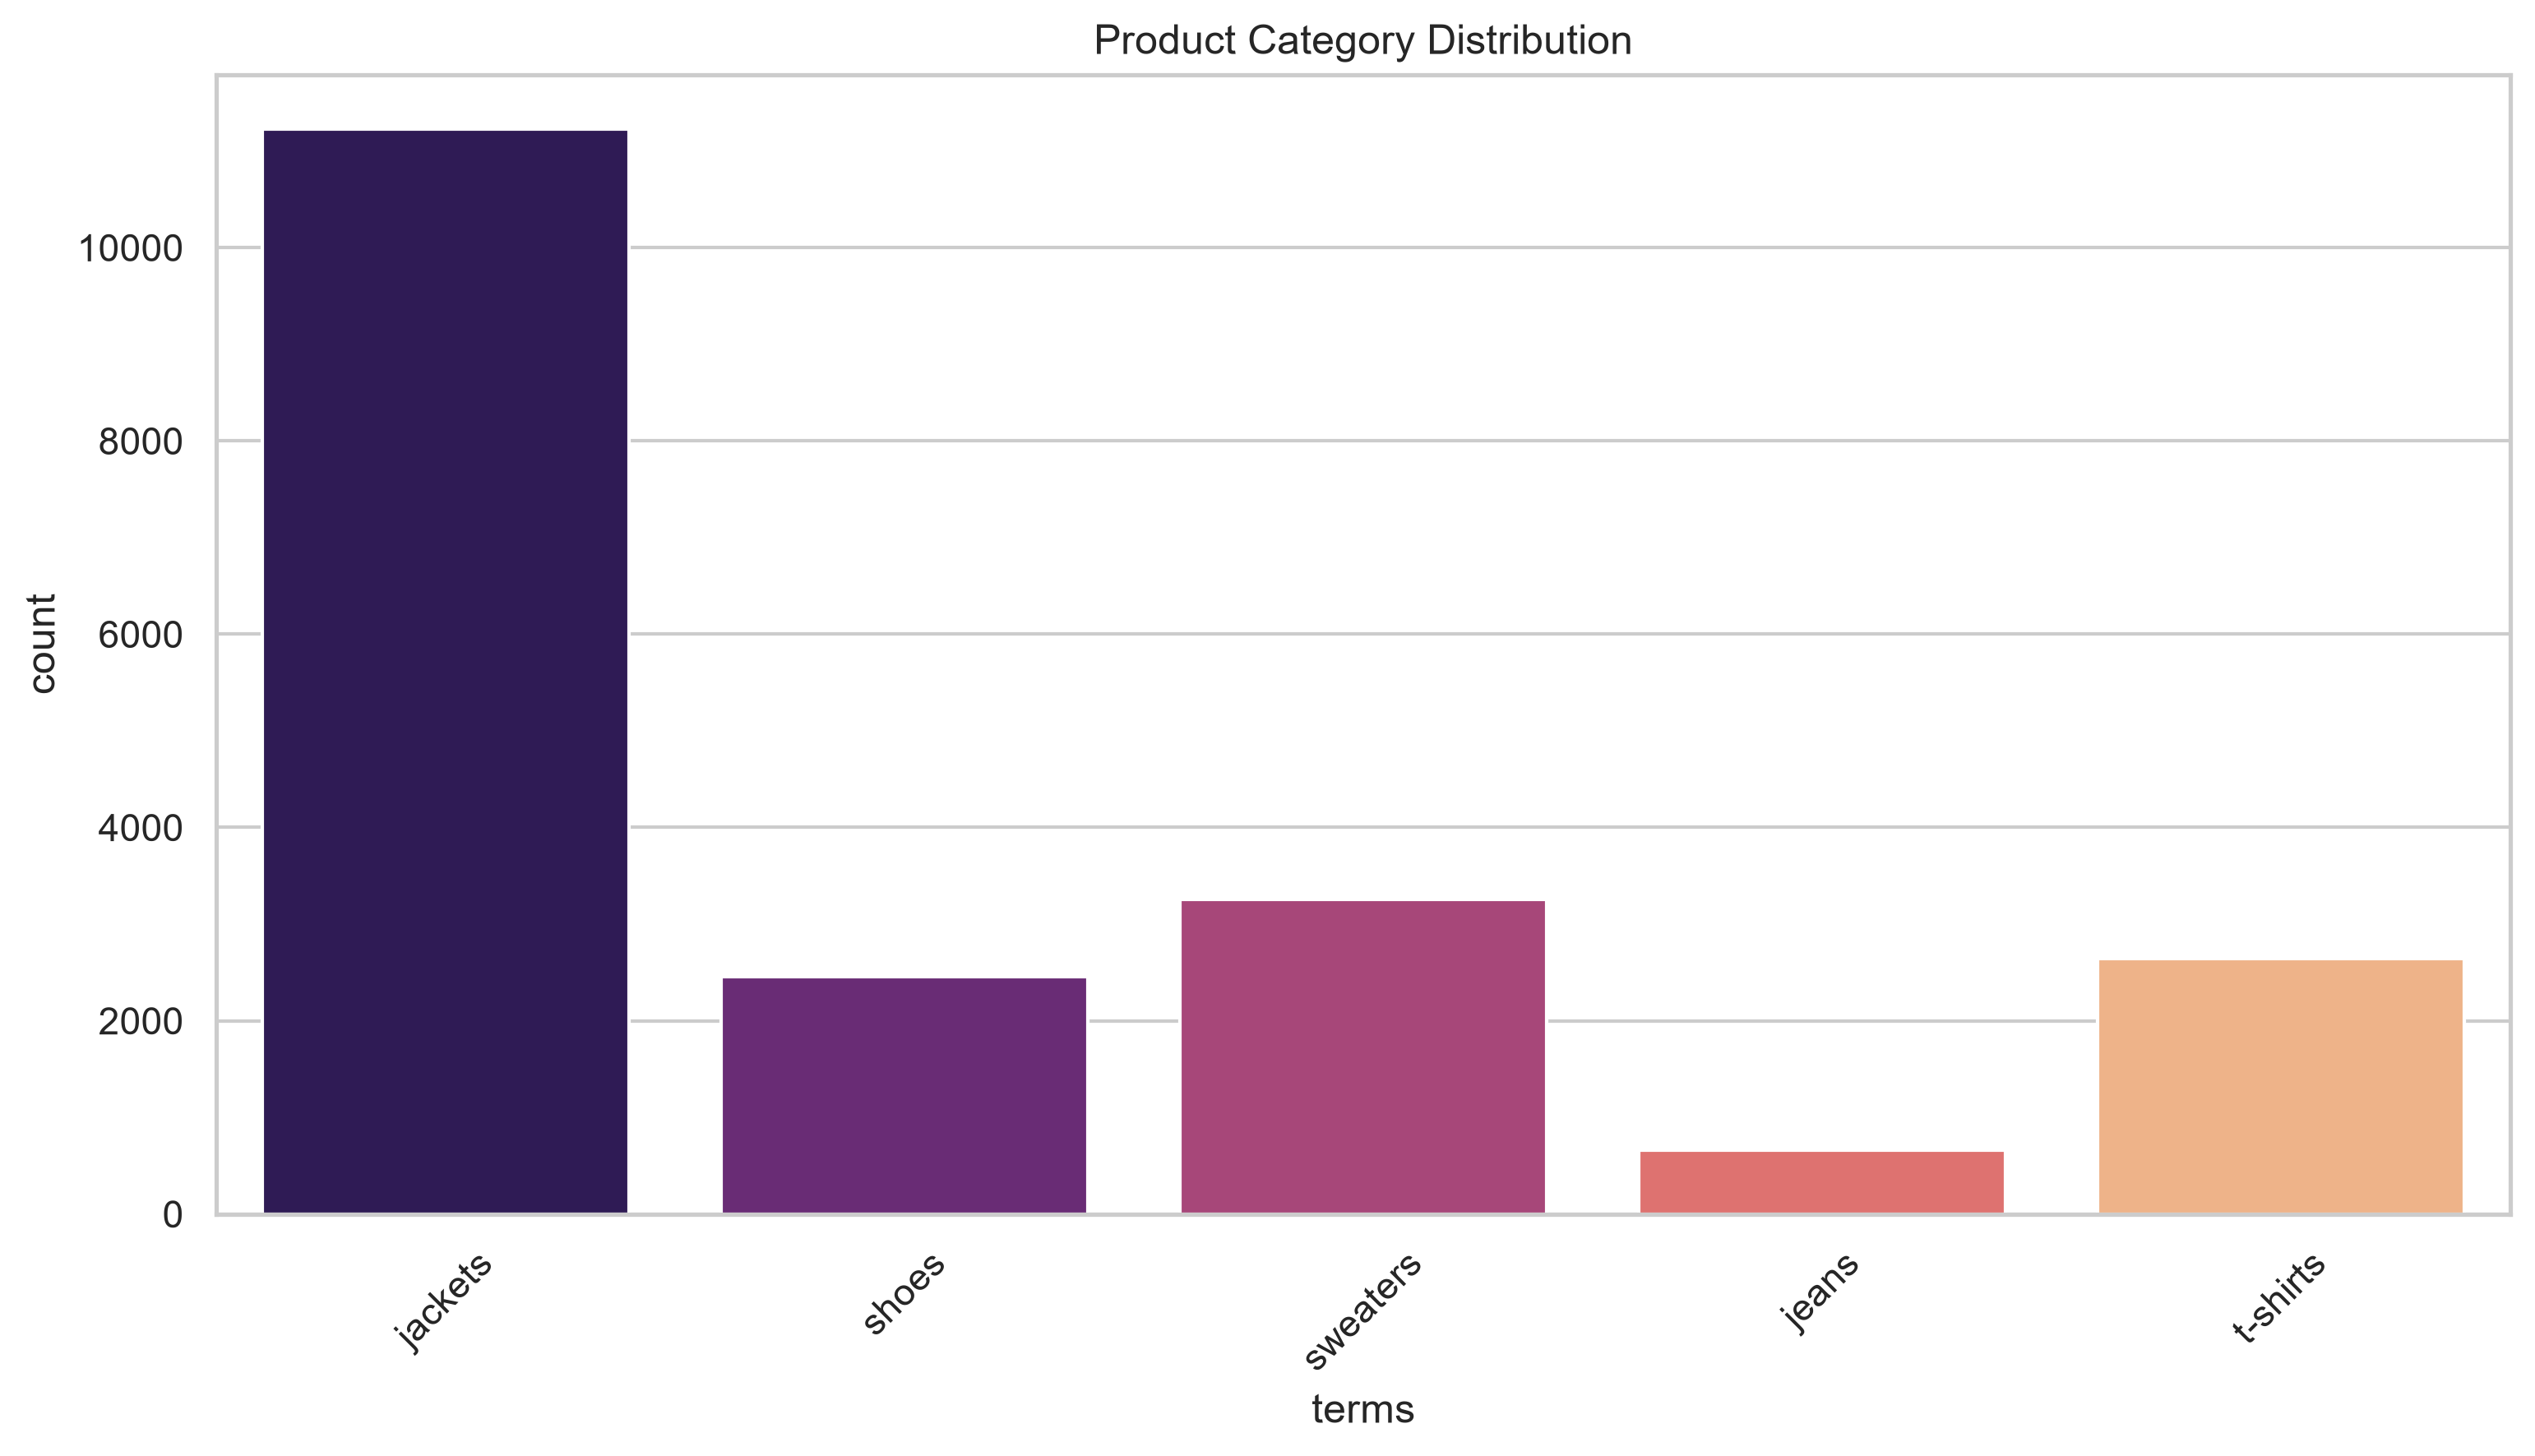

In [13]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "product_category_distribution.png")
Image(img_path)


However, once looking at the below boxplot you can see that Jackets have a widespread of selling prices and a lot of them sit in the £10-£40 range. Overall we can see that all categories sit fairly low in price which explains why the overall price distribution is low.

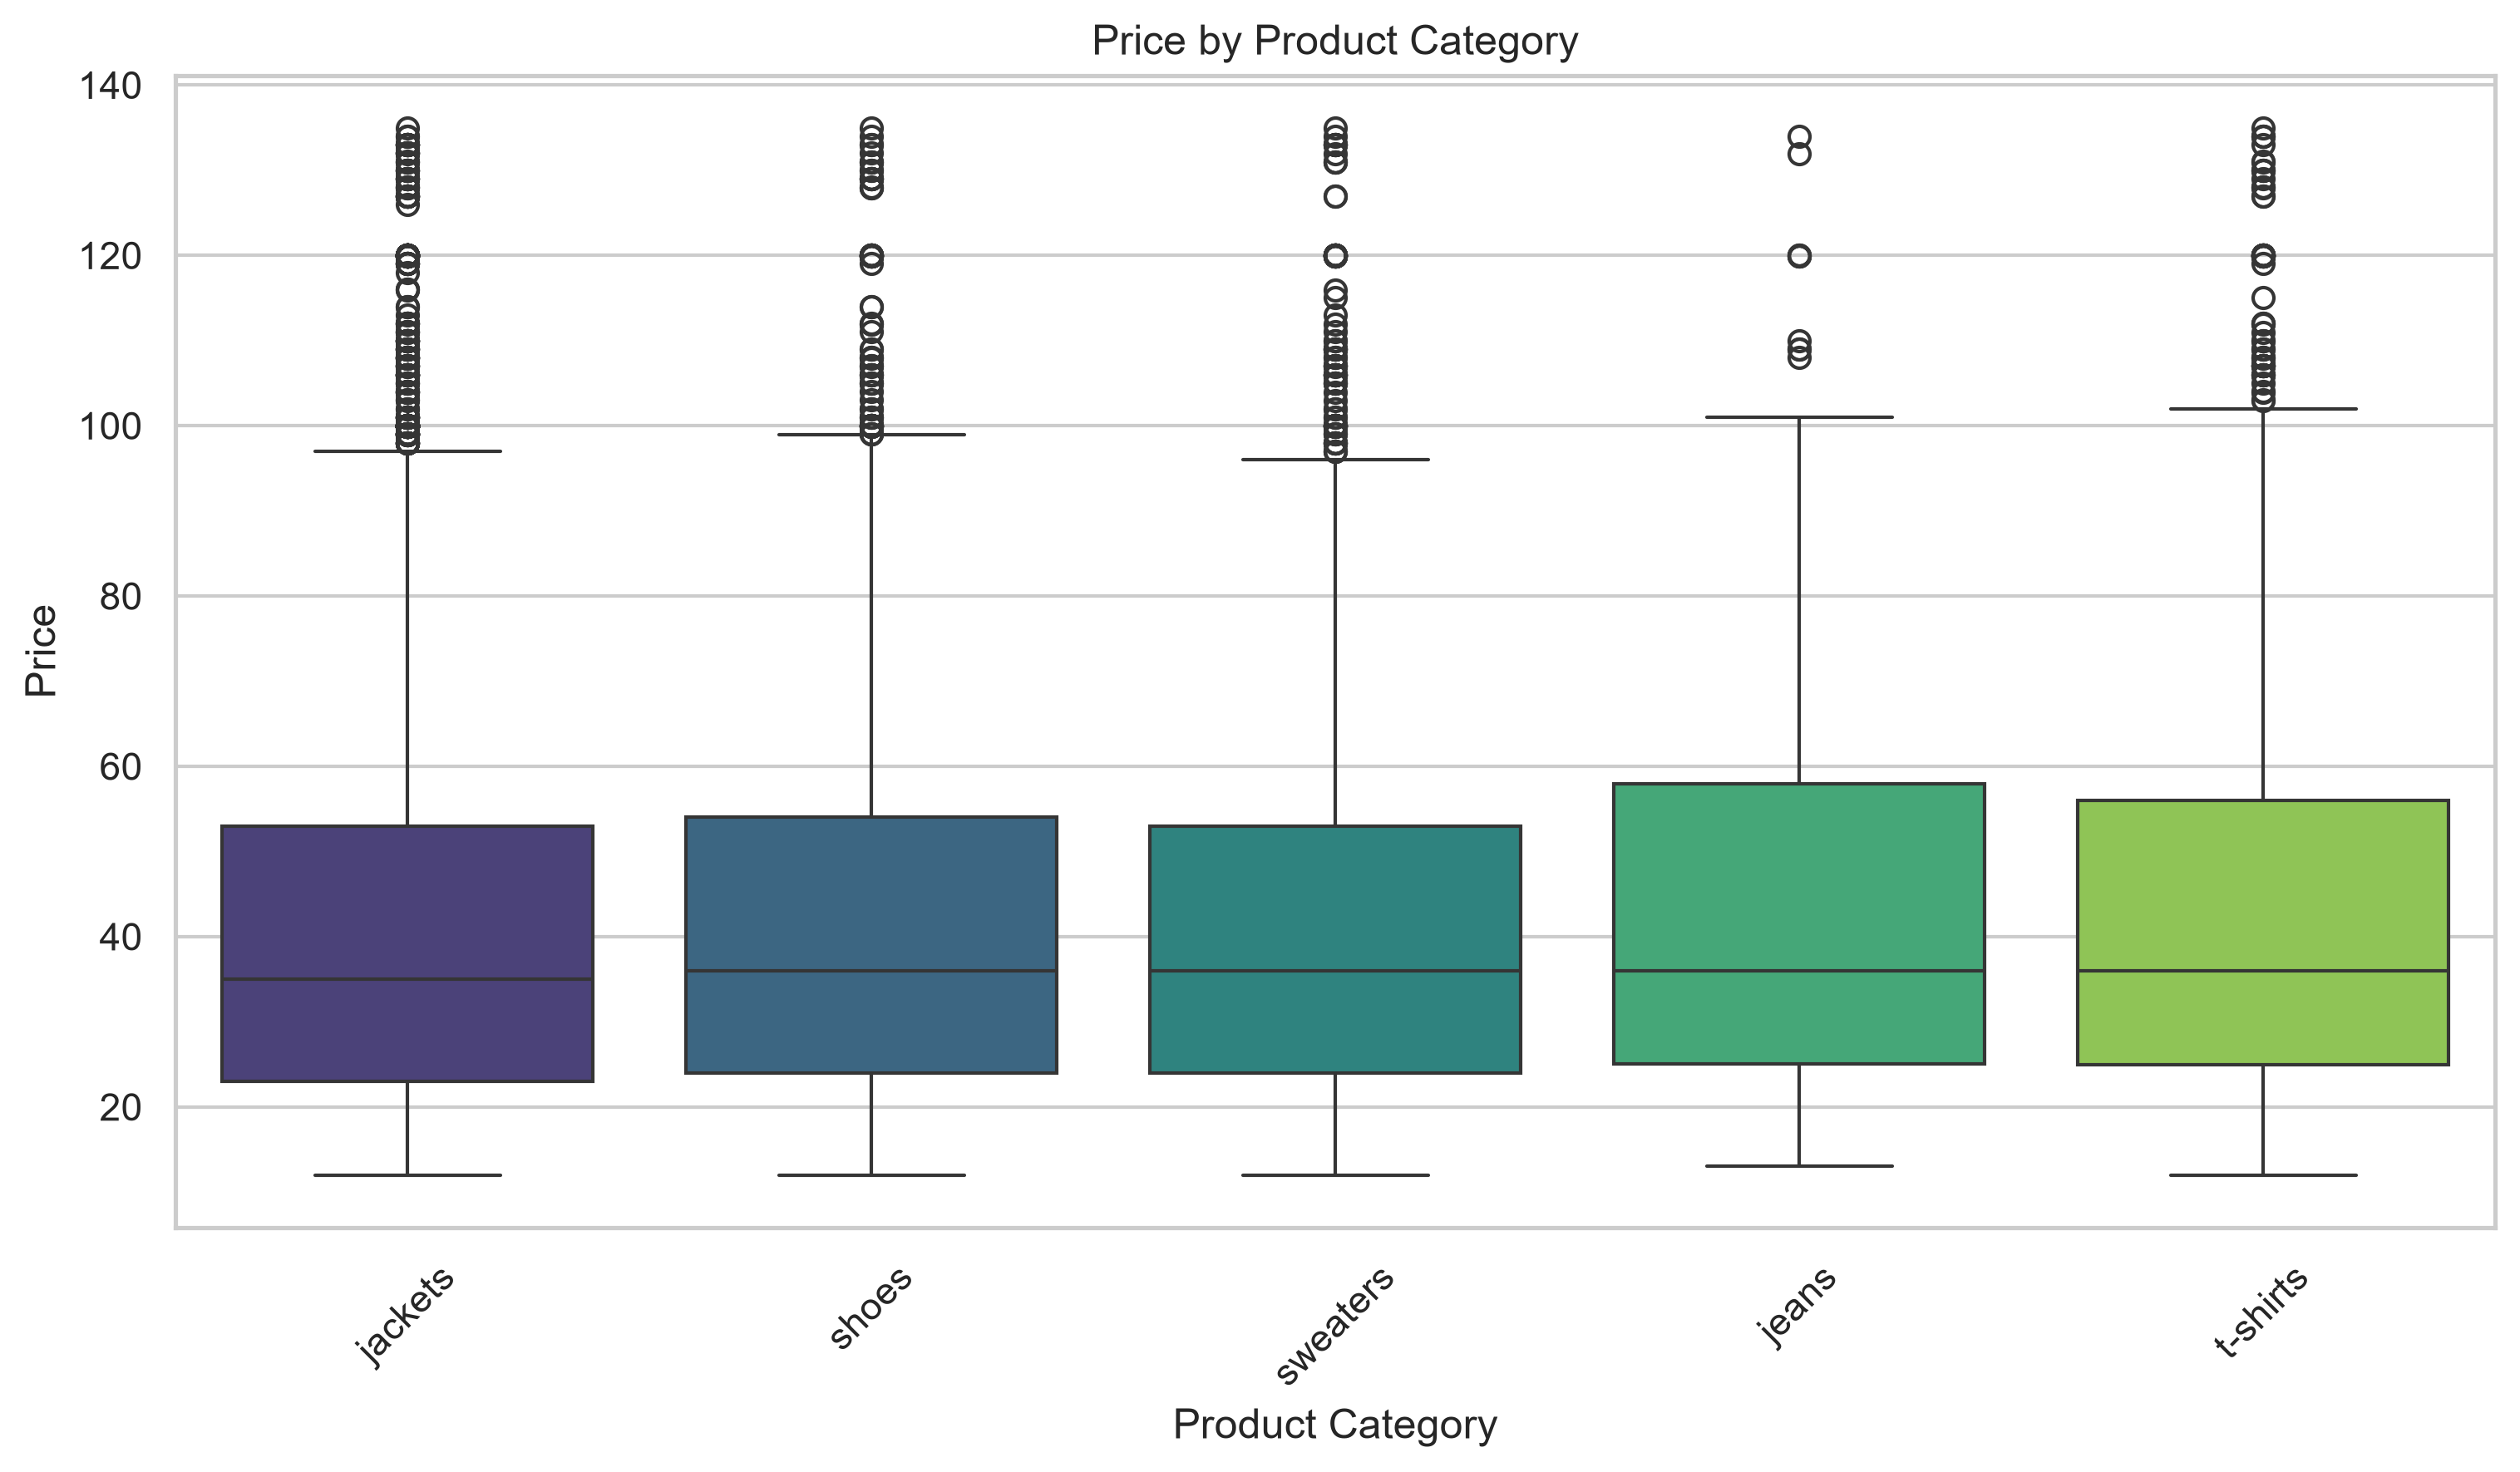

In [16]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "price_by_category.png")
Image(img_path)

### Sales Volume by Category

Looking at average sales by category we can see that no category massively outperforms or underperforms the other - they all sell averagely the same. This means that category alone isn't a strong driver of sales and it shifts the focus to other features play a bigger role in driving sales volume.

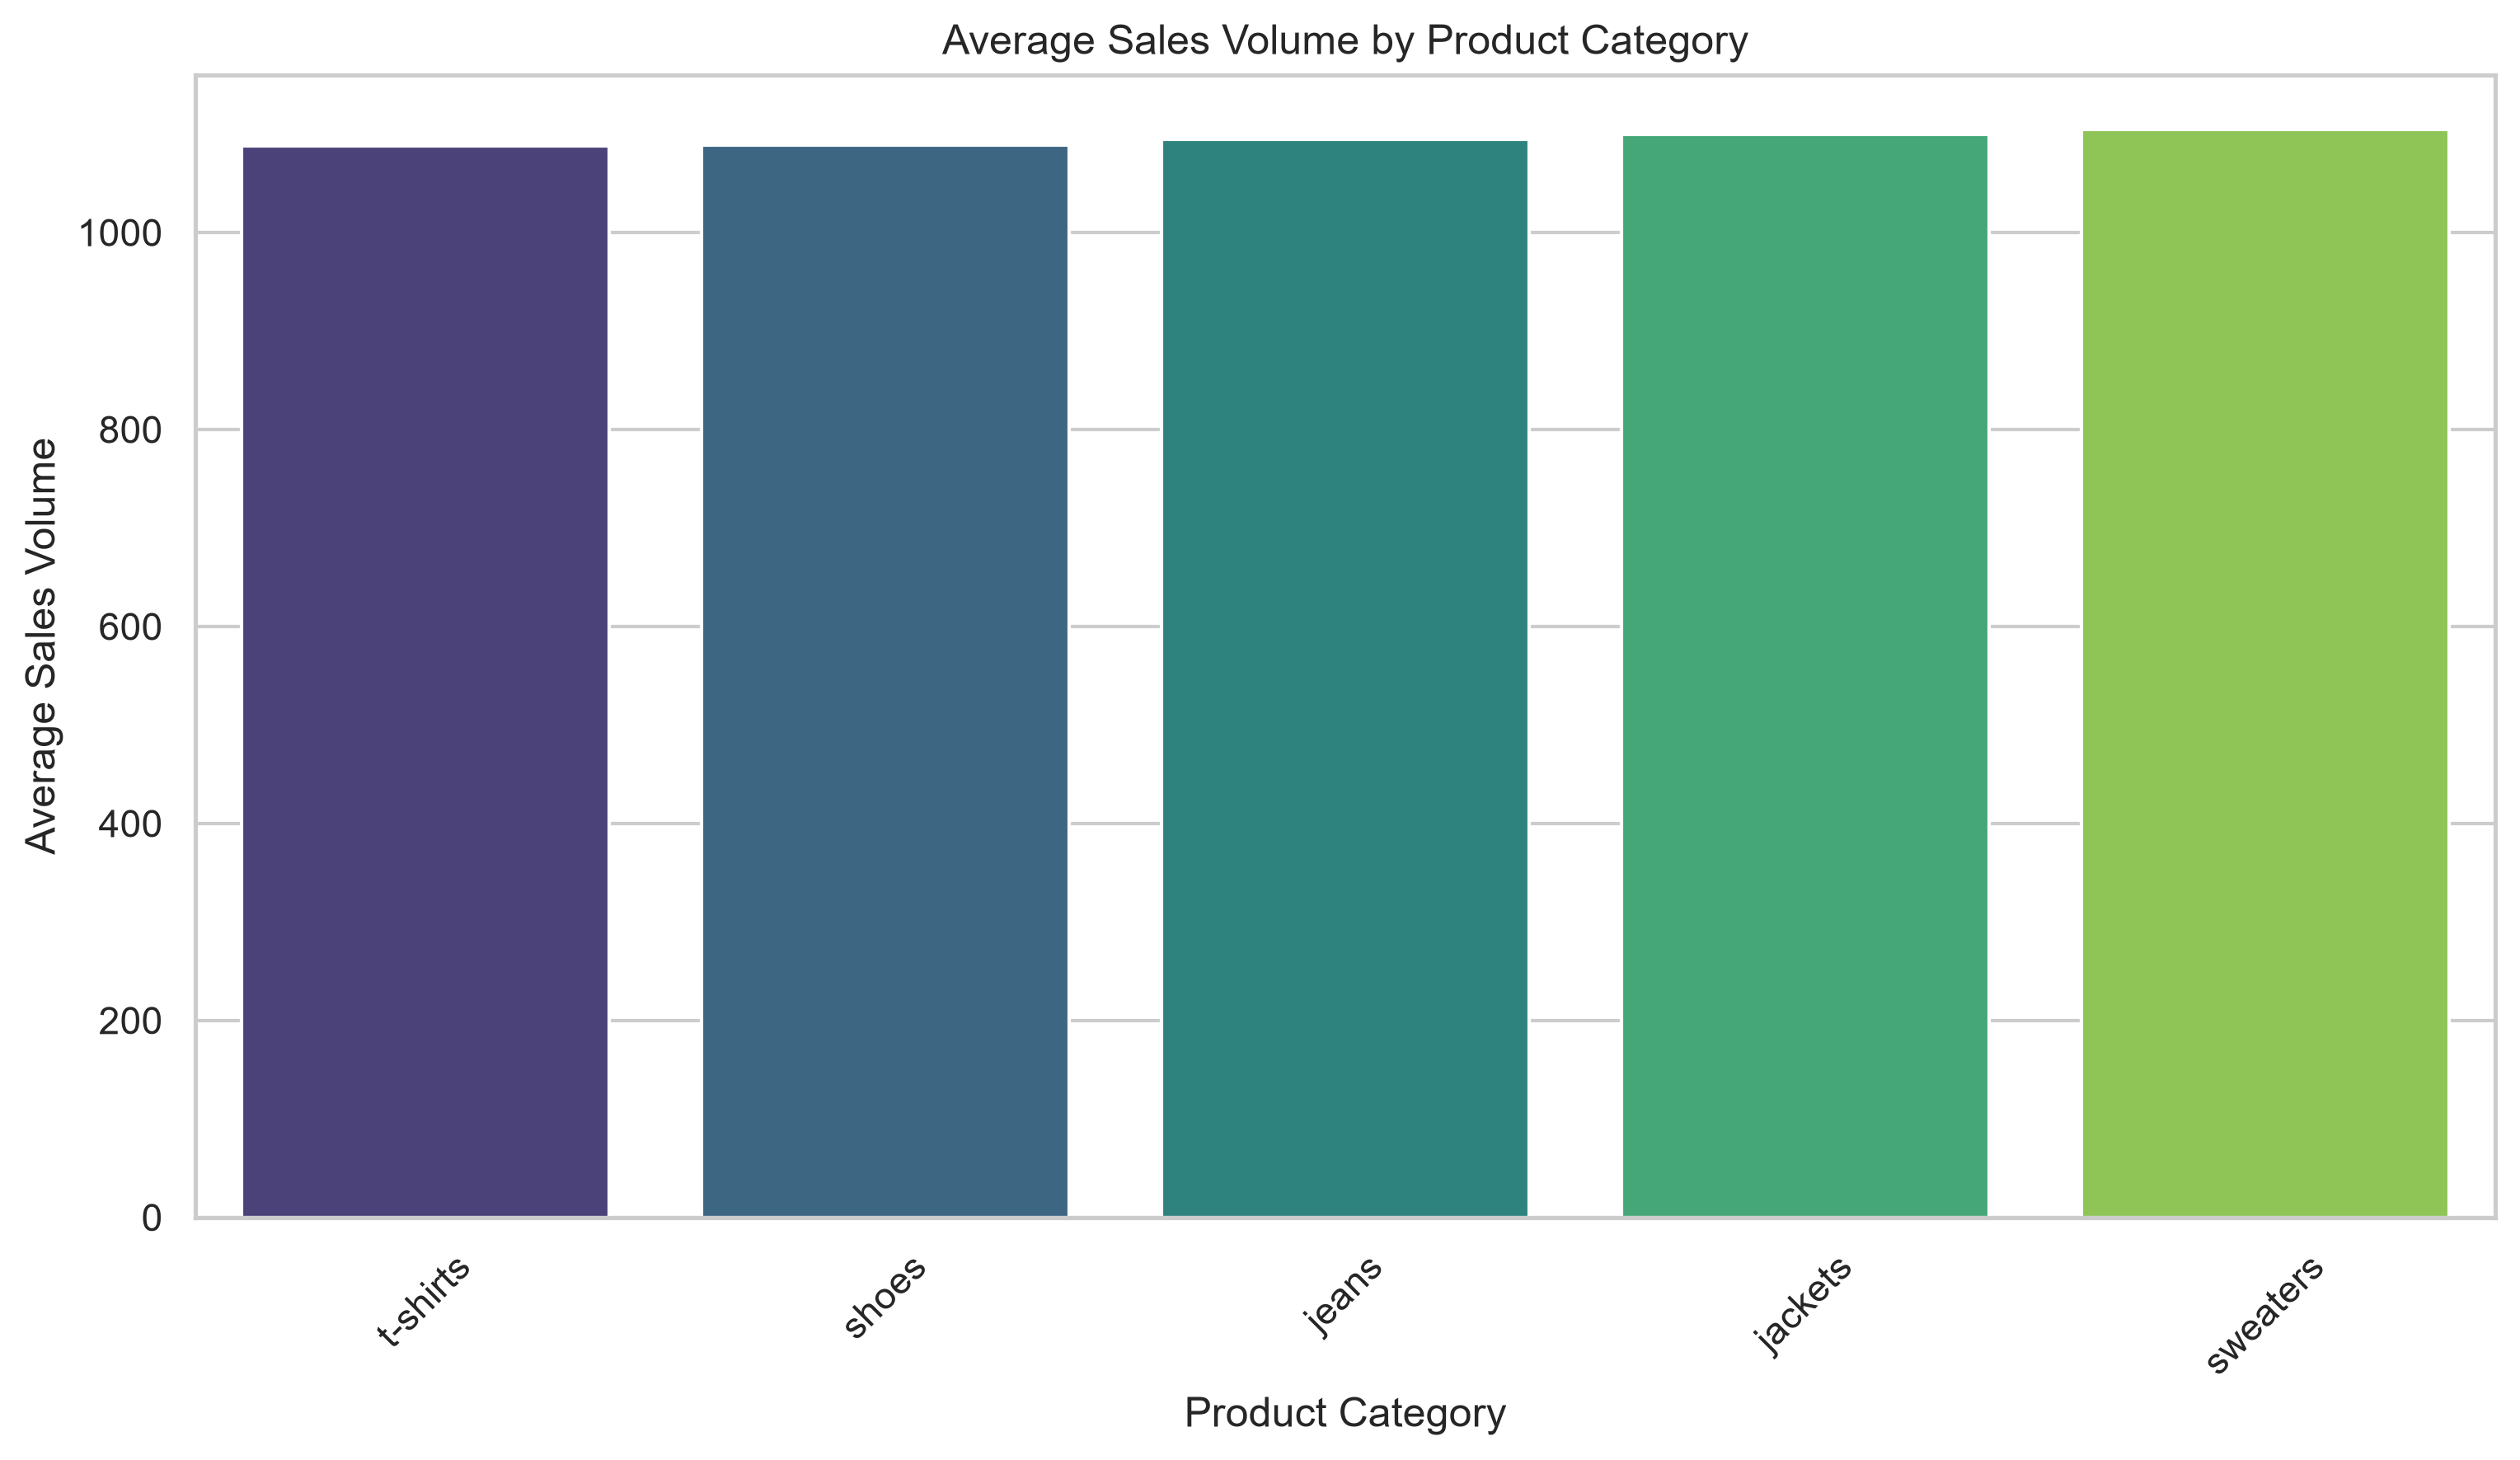

In [19]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "sales_volume_by_category.png")
Image(img_path)

### Sales Volume by Product Position

Reviewing sales volume by product position shows the averages across the different positons roughly the same. I had thought that front of store might drive more sales versus aisle might be more normal, that isn't the case.

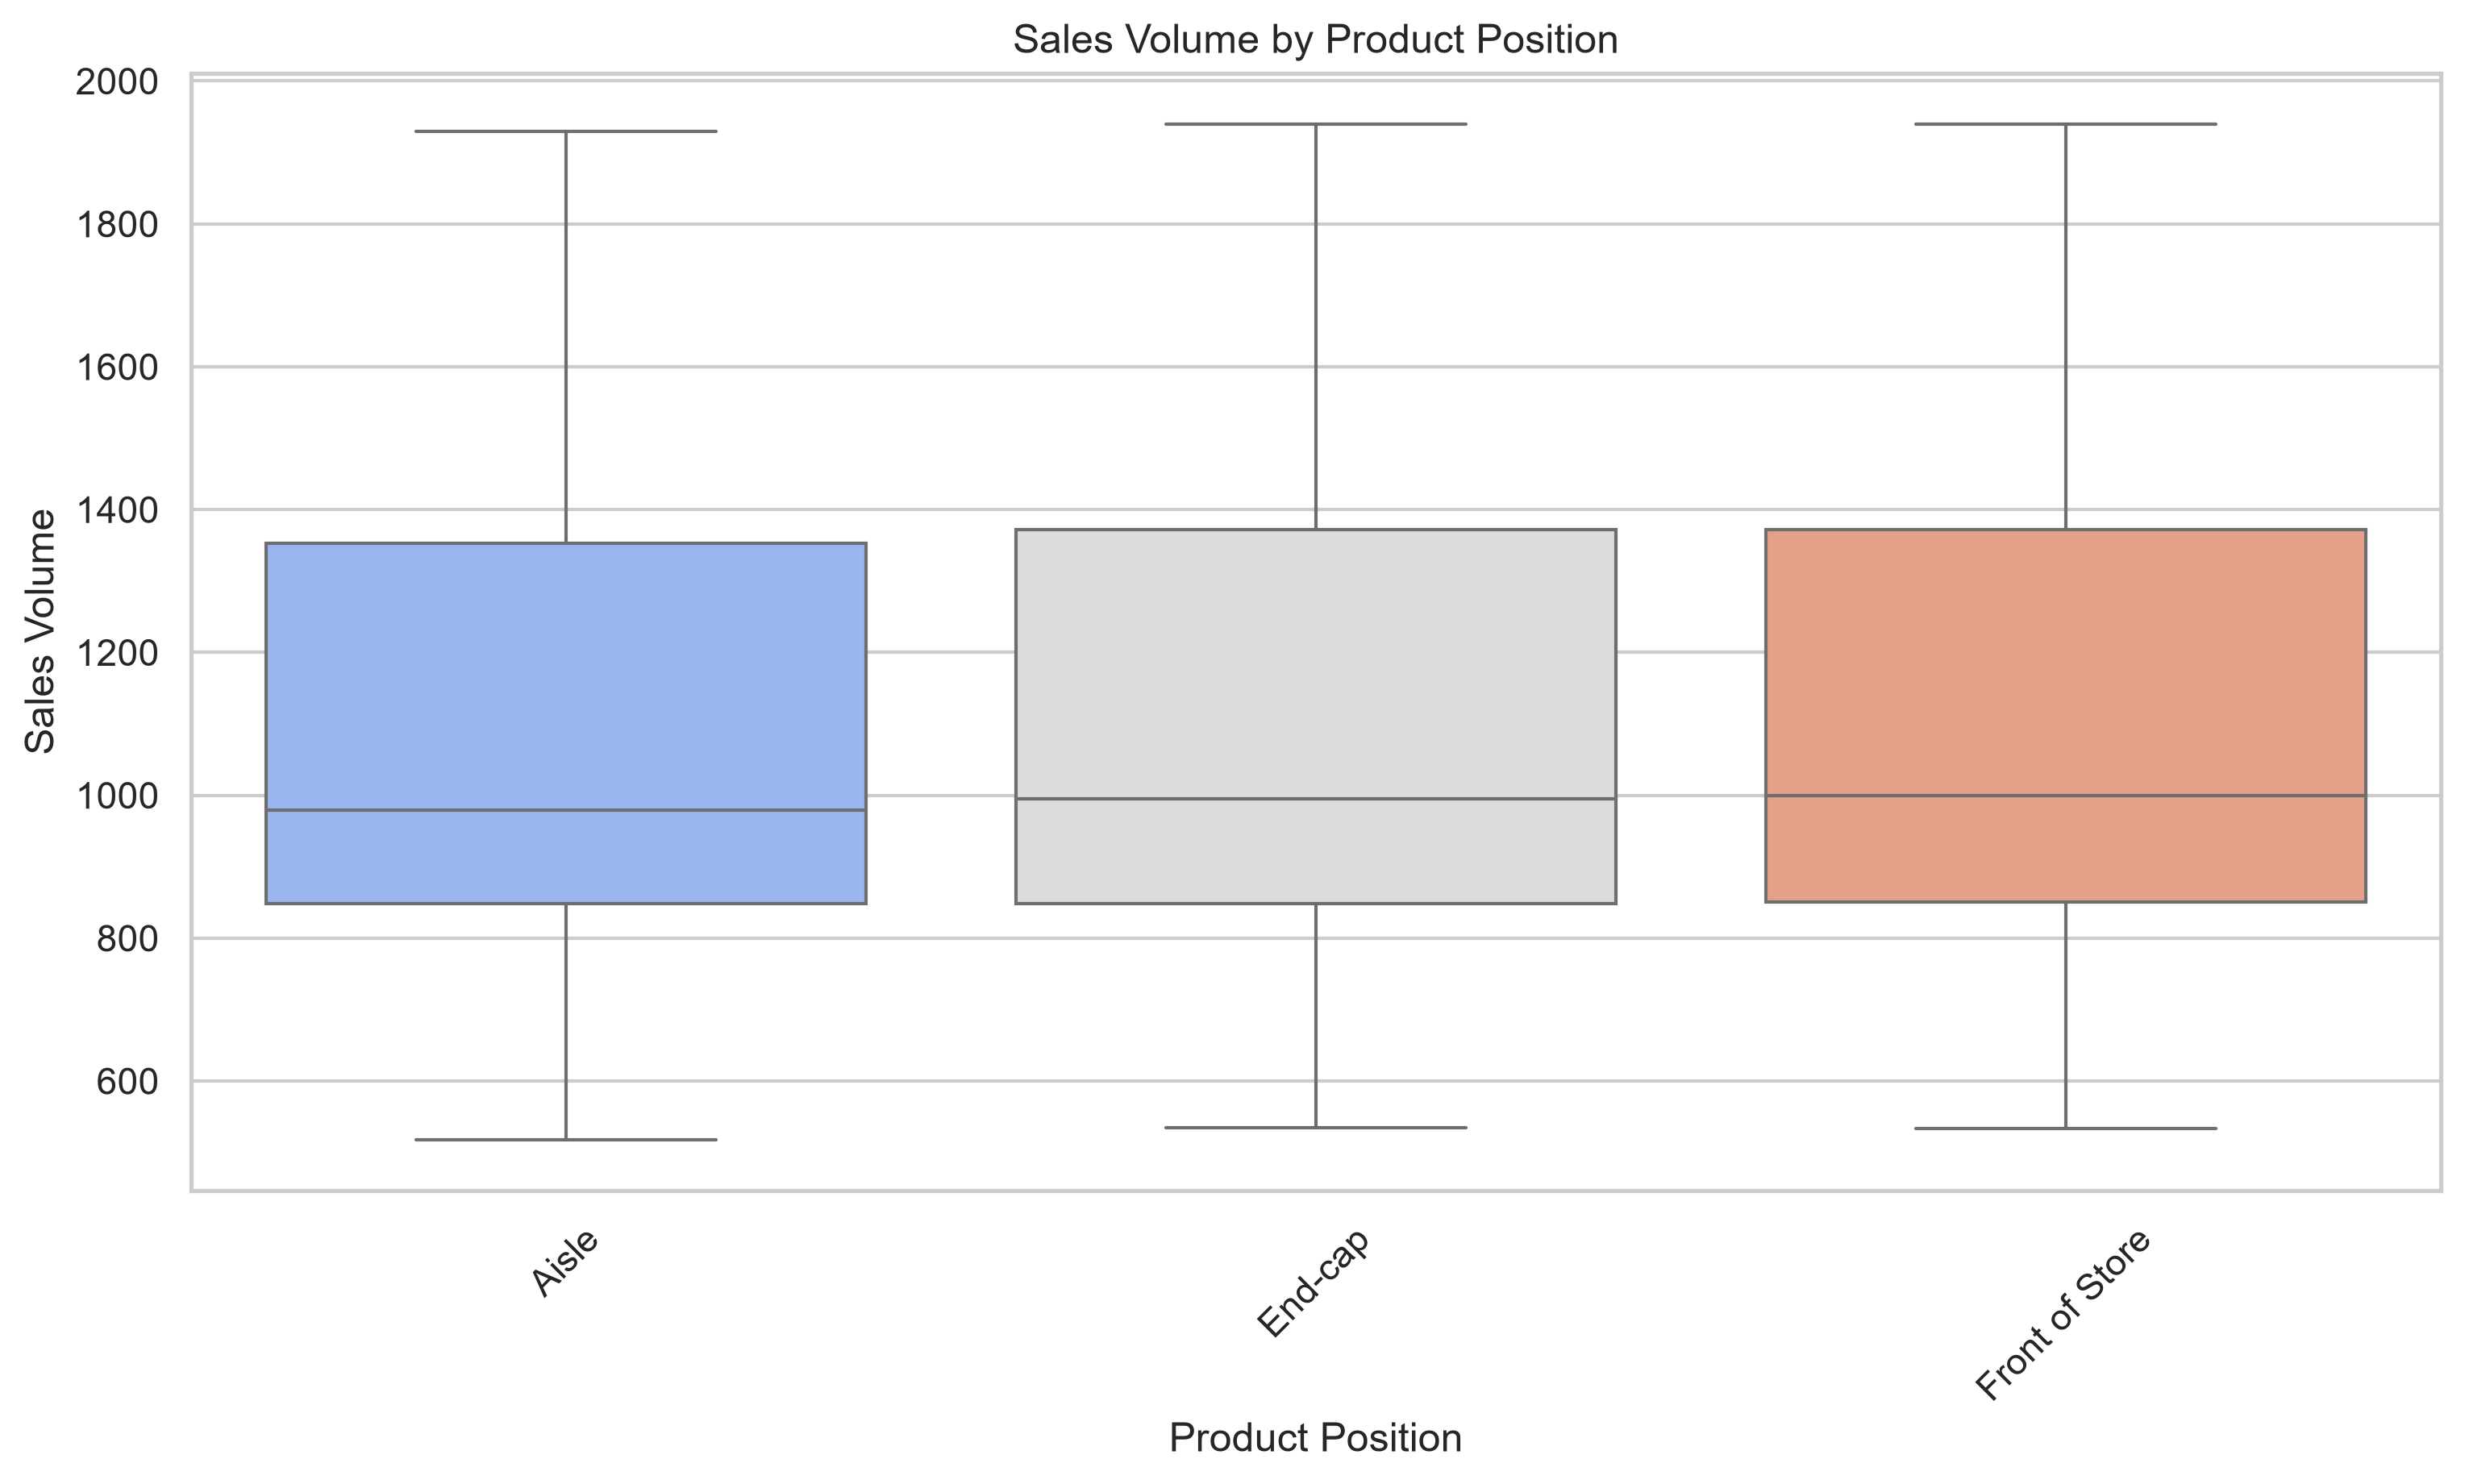

In [22]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "sales_volume_by_position.png")
Image(img_path)

### Promotion versus Sales Volume

After seeing that sales volume wasn't impacted by category or by position in store, I wanted to review the impact of being on promotion versus not on promotion. What we can see is that promotion is a big driver of sales volume. This also explains the two peaks in my sales histogram - one is non promoted items and the other promoted items.

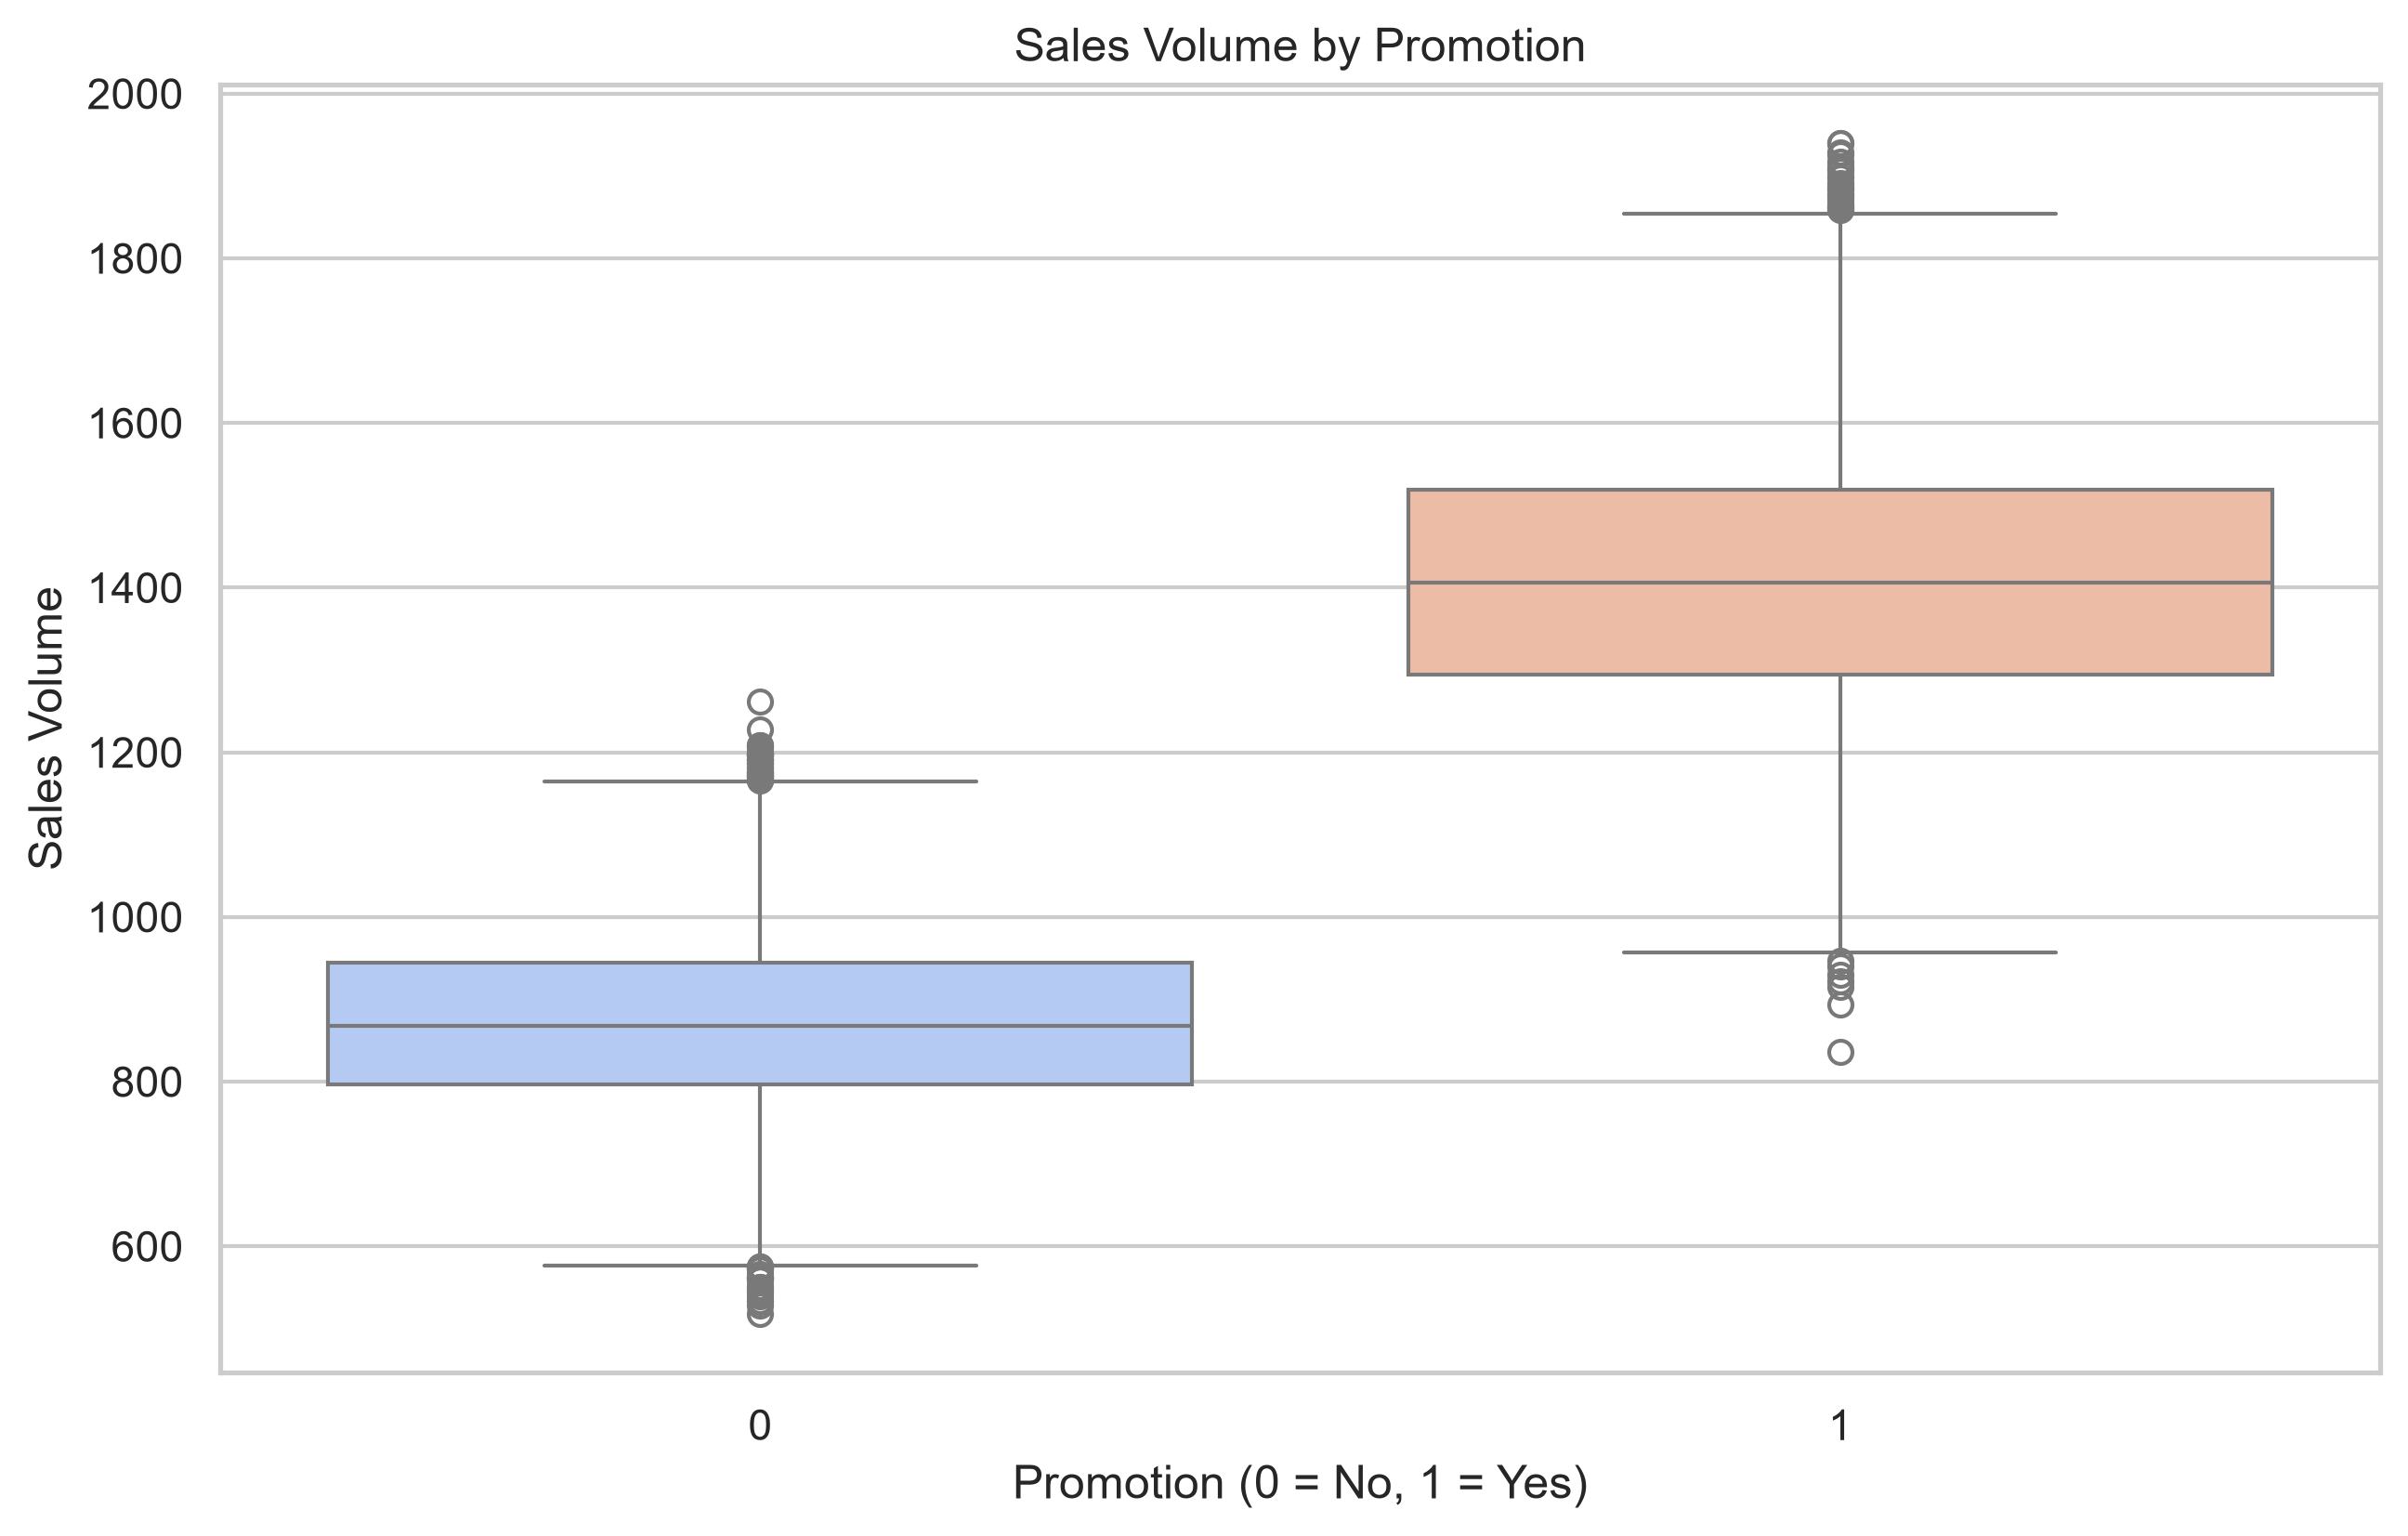

In [25]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "promotion_vs_sales_volume.png")
Image(img_path)

### Promotion Effectiveness

The below shows the average units sold with and without promotion. We can see that that products sell a lot more when they are promoted. This confirms that promotion is the strongest driver of sales in this dataset.

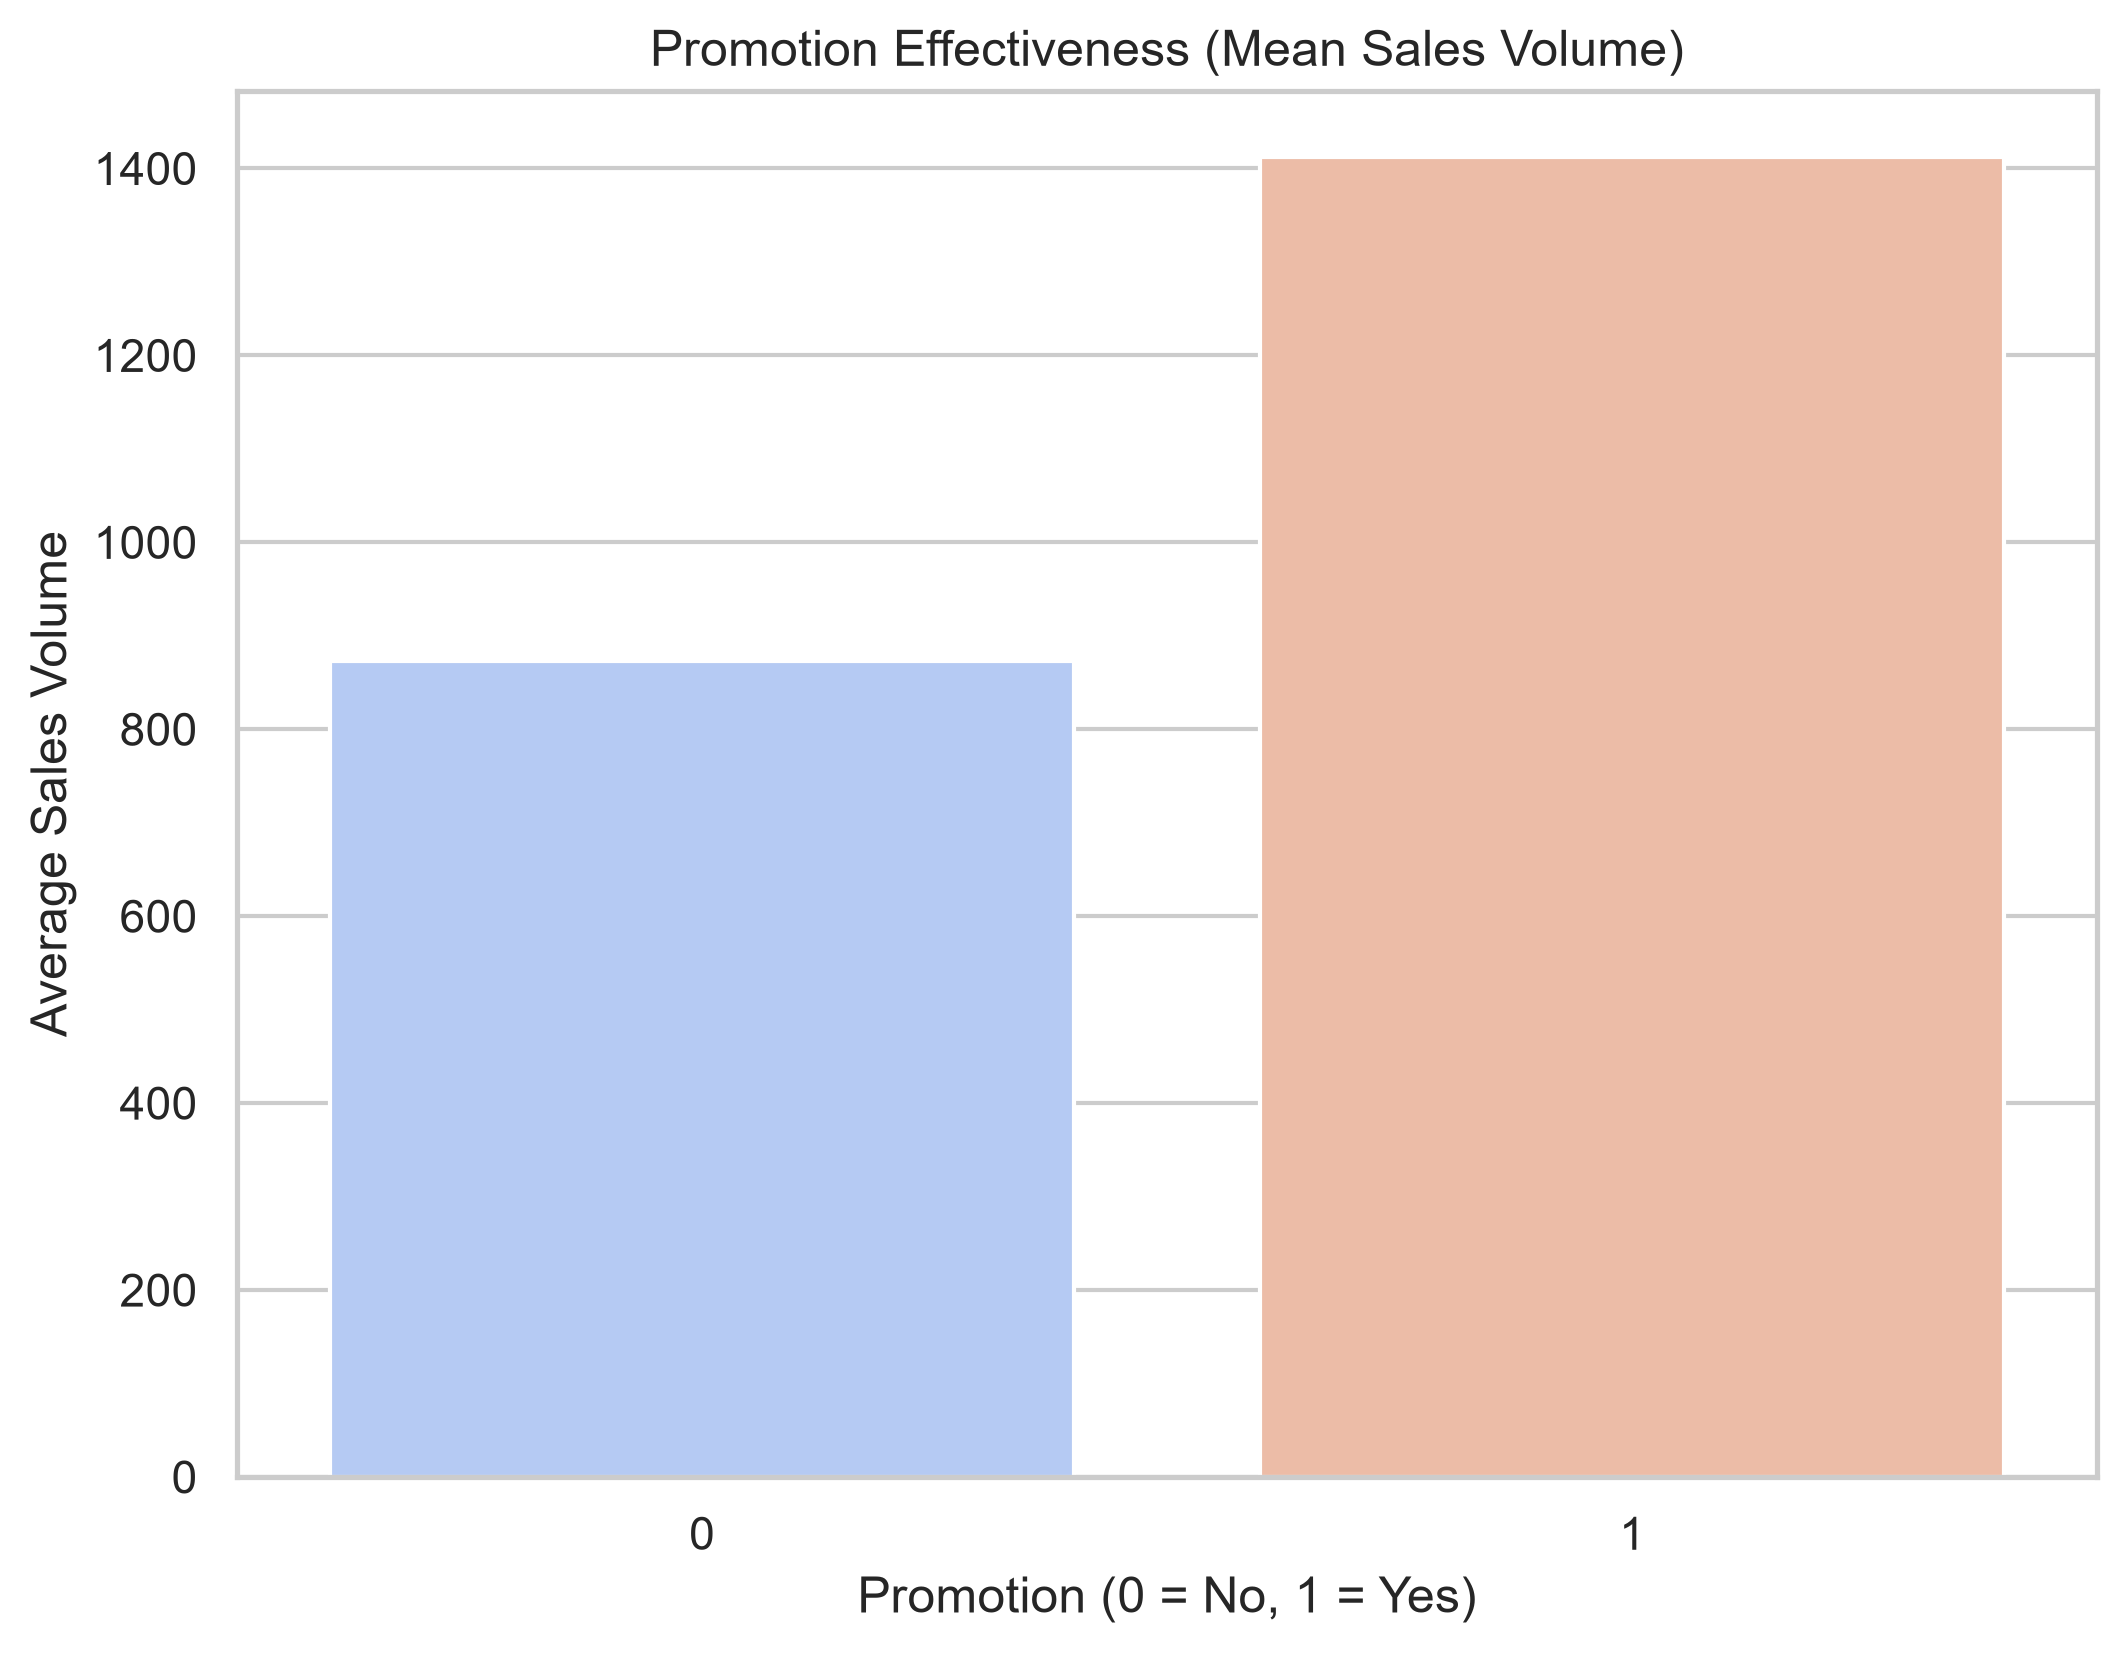

In [28]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "promotion_effectiveness.png")
Image(img_path)

### Price vs Sales Volume

This chart shows that cheaper items sell more, and we can see sales volume decline as price increases. This confirms that price is an important factor influencing demand.

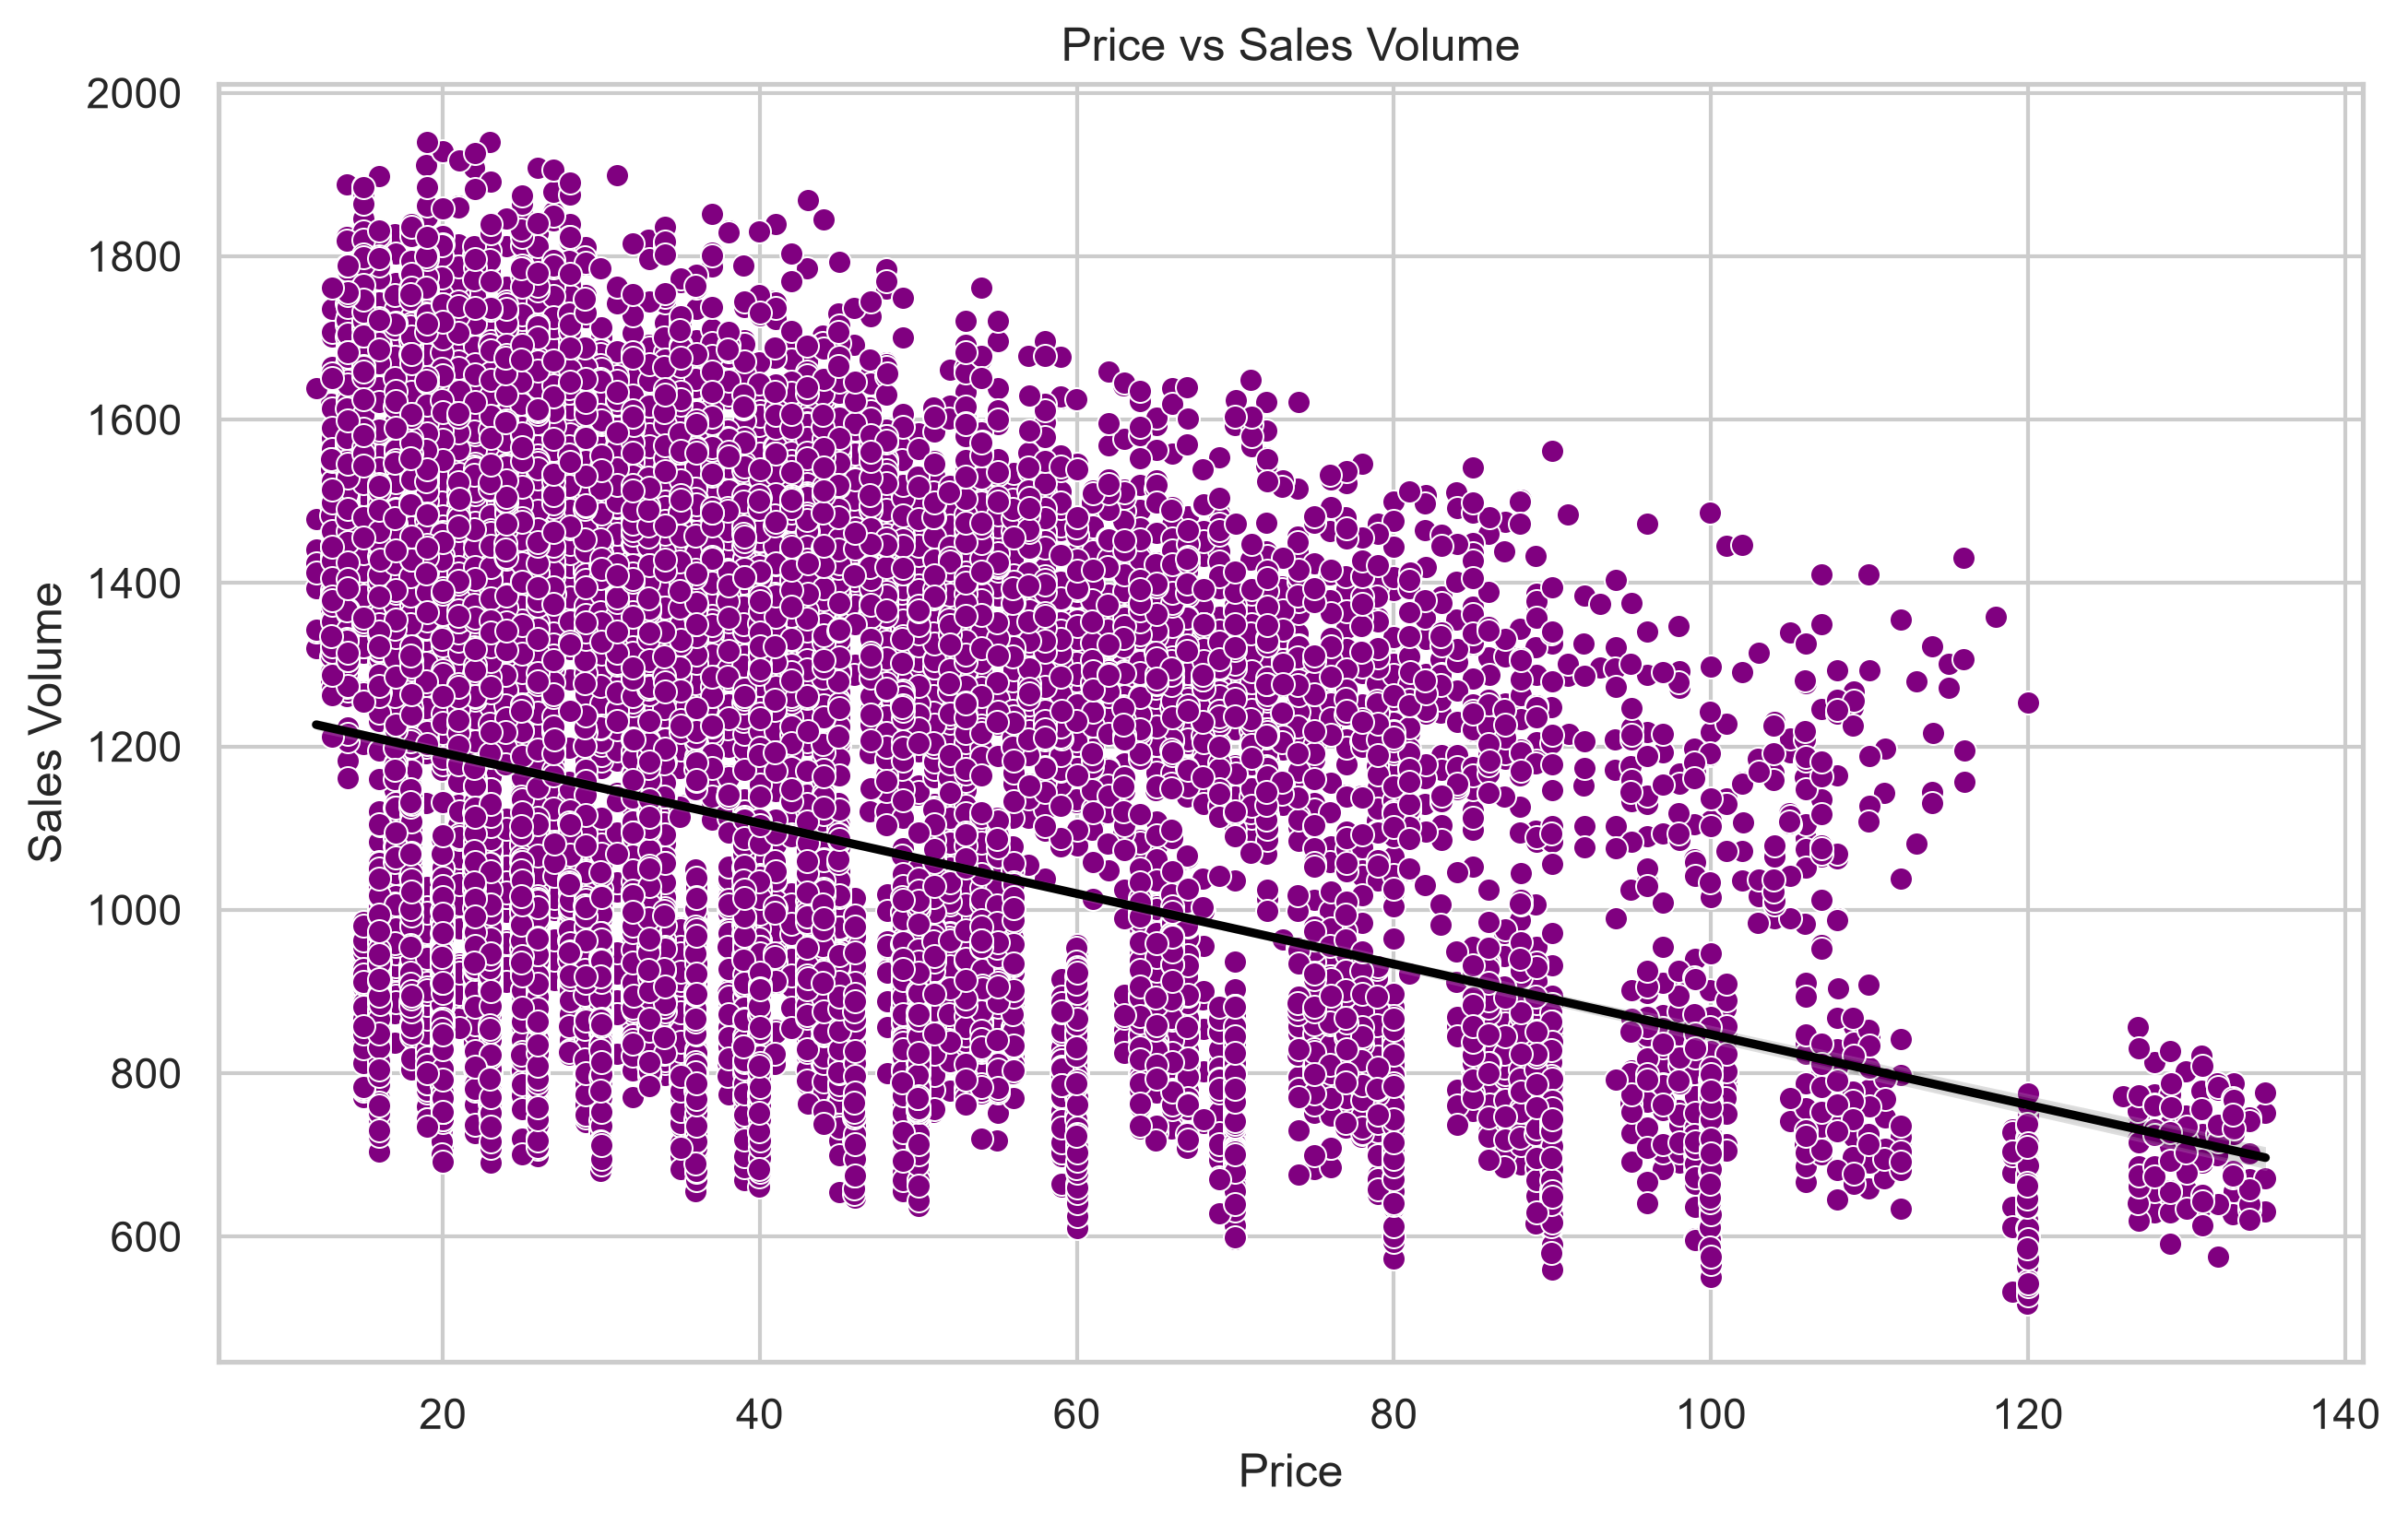

In [32]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "price_vs_sales_volume.png")
Image(img_path)

### Correlation Heatmap

From this heatmap we can see that promotion is the biggest driver of sales with a high correlation of 0.89. This means that when a product is promoted that sales volume increases significantly. Which is further backed up by price which is showing a negative correlation with sales volume, -0.34. This means that when the price is higher there are lower sales which indicates that customers are price sensitive. One other stands out which is promotion and seasonal which are moderately linked with a score of 0.27. This indicates that seasonal items are more likely to be promoted. This lines up with strategies often used in retail which is to promote seasonal products eg. if they have a lot of summer stock they need to get through, and promos are used to ensure they get through the volume of stock.

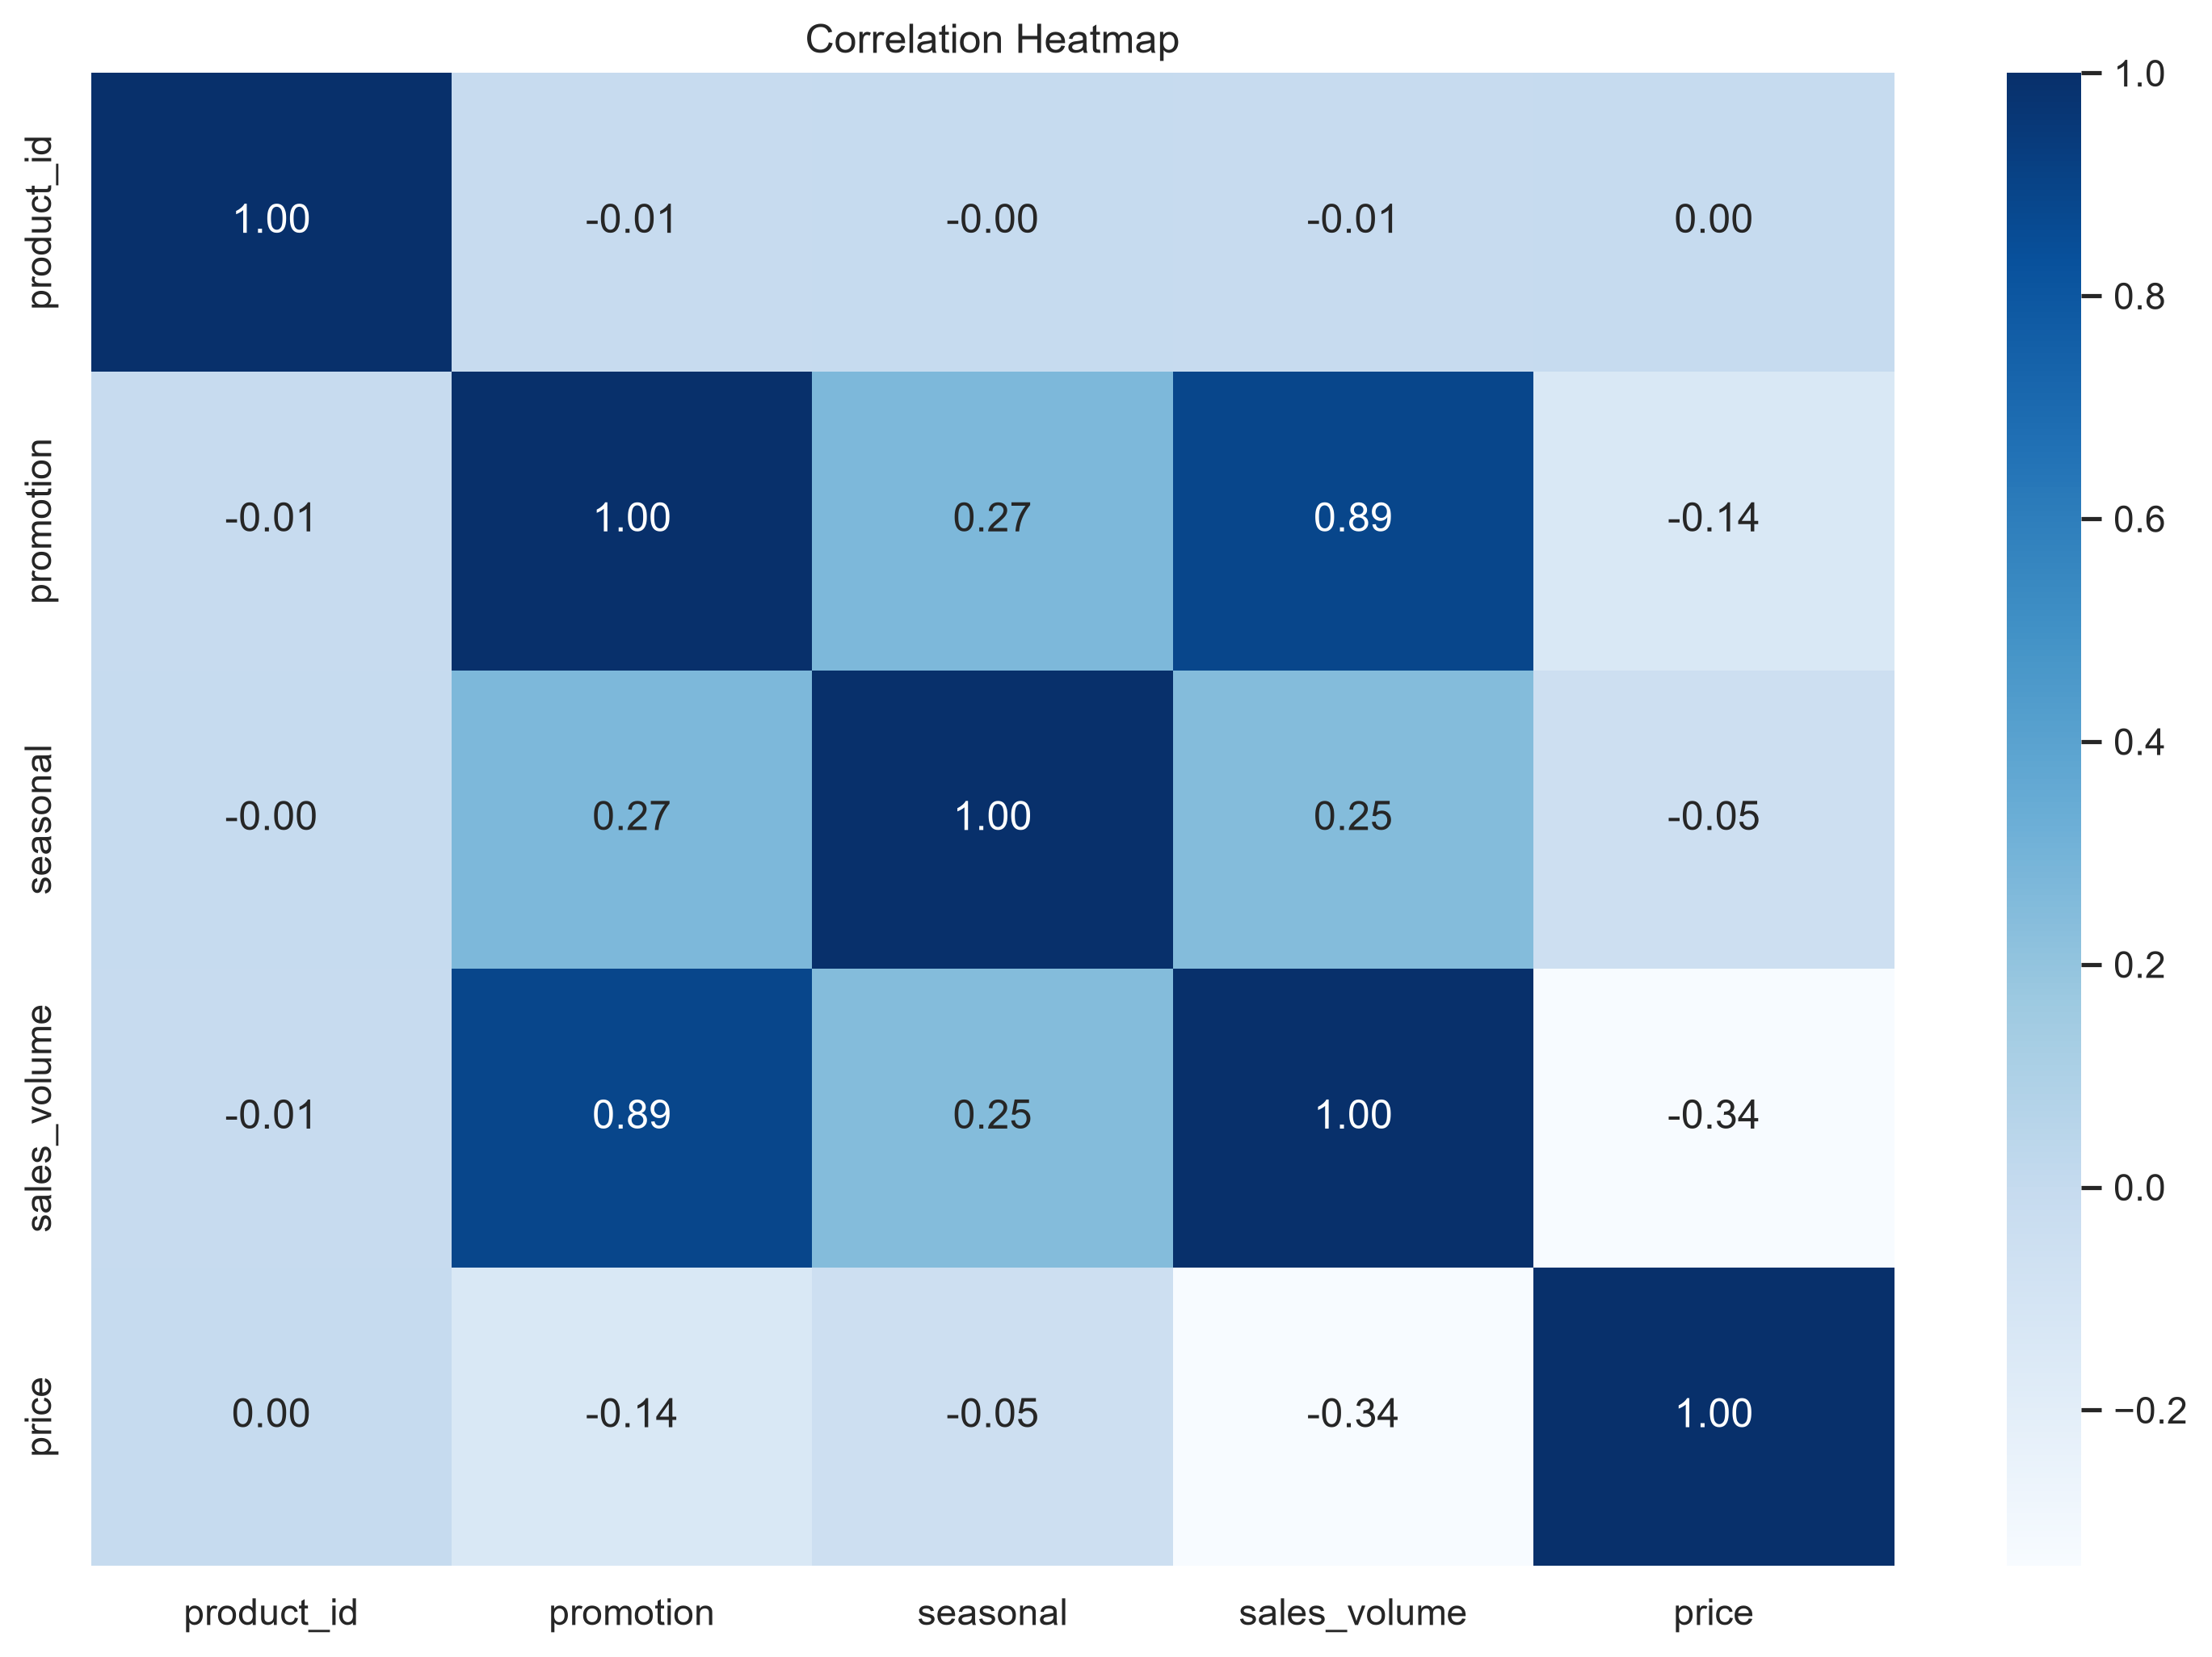

In [33]:
from IPython.display import Image

img_path = os.path.join(project_root, "visuals", "eda", "correlation_heatmap.png")
Image(img_path)

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [34]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)